# 06D — Soft-label Validation-only Audit

## Purpose

This notebook is a **training-free audit** of the existing single-stage soft-label experiments. It does not search for a new model and it does not use Test for any new decision.

It answers four questions:

1. Did the integrated soft-label experiments change only the target, or did they also change the sampler population, epoch length and class weights?
2. Are the corrected union-area soft labels aligned, bounded and reproducible relative to the historical 50% hard labels?
3. On the complete six-WSI Validation split, do Raw Soft or cutoff variants provide stable gains over the controlled hard-label baseline?
4. Is the apparent signal for **Irregular epithelial stratification** supported across WSIs and concentrated in meaningful boundary/context cases?

All outputs are written to:

```text
outputs/rq1_soft_label_validation_audit/
```


## Locked interpretation boundaries

- **Validation only. Test is never loaded in this notebook.**
- Main model comparison uses the existing **AUC-selected checkpoints**, matching the controlled baseline protocol.
- `0.5` is retained as the historical fixed decision threshold for threshold-based diagnostics. Ranking metrics are also reported because they do not depend on a threshold.
- Patch-level observations within a WSI are not treated as independent evidence. Robustness is assessed by per-WSI results and leave-one-WSI-out exclusion analysis.
- A soft-label model is not accepted as a replacement merely because AUROC increases. AUPRC, recall and F1 must also be considered under extreme imbalance.
- Boundary patches with `0 < soft overlap < 0.5` are described as **uncertain boundary patches**, not automatically as true positives or true negatives.
- Image review is evidence collection, not an automatic diagnosis. The notebook cannot mark a local signal as confirmed until the generated review sheet has been manually inspected.

### Pre-registered decision logic

**Overall replacement** is rejected unless Raw Soft improves Validation ranking quality without a meaningful loss in recall/F1.

**Class-specific local signal** for Irregular epithelial stratification can proceed only if:

1. the gain exists on Validation;
2. it remains positive after excluding individual WSIs in most exclusions;
3. it is not explained by one WSI alone;
4. AUPRC or recall is not materially worse;
5. manual inspection supports genuine boundary/context information.


In [1]:
from __future__ import annotations

import ast
import gc
import hashlib
import json
import os
import random
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from PIL import Image, ImageDraw
from sklearn.metrics import (
    average_precision_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

# =============================================================================
# User switches
# =============================================================================

SEED = 42
FIXED_THRESHOLD = 0.5
RECALL_F1_TOLERANCE = 0.005
TILE_SIZE = 224

# Existing Validation probability arrays are preferred. If they are absent, frozen
# checkpoint inference can be run once and cached by this notebook.
ALLOW_INFERENCE_FALLBACK = True
RECOMPUTE_PROBABILITY_CACHE = False
INFERENCE_BATCH_SIZE = 256
INFERENCE_NUM_WORKERS = 8

# Cutoff variants are part of the audit but do not control the final conclusion.
INCLUDE_CUTOFF_MODELS = True

# Image review is Validation-only. Set environment variable SOFT_AUDIT_IMAGE_REVIEW=0
# for a quick non-visual dry run.
RUN_IMAGE_REVIEW = os.environ.get("SOFT_AUDIT_IMAGE_REVIEW", "1") == "1"
NUM_REVIEW_EXAMPLES_PER_CATEGORY = 8
MAX_EXAMPLES_PER_WSI = 2

# This must remain False until the exported review sheet/contact sheets are examined.
MANUAL_REVIEW_CONFIRMED = False

# Strict project counts are enabled for the real experiment and disabled only for tests.
STRICT_EXPECTED_COUNTS = os.environ.get("SOFT_AUDIT_STRICT_COUNTS", "1") == "1"
EXPECTED_TRAIN_ROWS = 1_359_460
EXPECTED_VAL_ROWS = 198_083
EXPECTED_VAL_WSIS = 6
EXPECTED_NUM_CLASSES = 12

LABEL_COLUMNS = [
    "Irregular epithelial stratification",
    "Loss of polarity of basal cells",
    "Drop shaped rete ridges",
    "Premature keratinization in single cells",
    "Loss of epithelial cell cohesion",
    "Abnormal variation in nuclear size",
    "Abnormal variation in nuclear shape",
    "Abnormal variation in cell size",
    "Abnormal variation in cell shape",
    "Increased N:C ratio",
    "Increased number and size of nucleoli",
    "Hyperchromasia",
]
TARGET_CLASS = "Irregular epithelial stratification"
TARGET_CLASS_INDEX = LABEL_COLUMNS.index(TARGET_CLASS)

MODEL_ORDER = [
    "Controlled_Hard",
    "Integrated_RawSoft",
    "Integrated_SoftCutoff_0.1",
    "Integrated_SoftCutoff_0.2",
    "Integrated_SoftCutoff_0.3",
]
if not INCLUDE_CUTOFF_MODELS:
    MODEL_ORDER = MODEL_ORDER[:2]

PROTOCOL = {
    "experiment": "06D Soft-label Validation-only Audit",
    "seed": SEED,
    "split_policy": "Validation only; Test never loaded",
    "fixed_threshold": FIXED_THRESHOLD,
    "target_class": TARGET_CLASS,
    "model_order": MODEL_ORDER,
    "ranking_metrics": ["micro_auroc", "macro_auroc", "micro_auprc", "macro_auprc"],
    "threshold_metrics": ["micro_precision", "micro_recall", "micro_f1", "macro_precision", "macro_recall", "macro_f1"],
    "cluster_robustness": "per-WSI and leave-one-WSI-out exclusion",
    "manual_review_required": True,
}
PROTOCOL_JSON = json.dumps(PROTOCOL, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
PROTOCOL_SHA256 = hashlib.sha256(PROTOCOL_JSON.encode("utf-8")).hexdigest()

random.seed(SEED)
np.random.seed(SEED)

print("Protocol SHA-256:", PROTOCOL_SHA256)
print("Models:", MODEL_ORDER)
print("Target class:", TARGET_CLASS)
assert len(LABEL_COLUMNS) == EXPECTED_NUM_CLASSES
assert MANUAL_REVIEW_CONFIRMED is False, "Do not pre-confirm manual review before examining exported examples."


Protocol SHA-256: af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd5659ad1a6669d3b059e70
Models: ['Controlled_Hard', 'Integrated_RawSoft', 'Integrated_SoftCutoff_0.1', 'Integrated_SoftCutoff_0.2', 'Integrated_SoftCutoff_0.3']
Target class: Irregular epithelial stratification


In [2]:
# =============================================================================
# Project-root and artifact resolution
# =============================================================================

ROOT_CANDIDATES = [
    Path(os.environ["JIANGJIE_PROJECT_ROOT"]).expanduser() if os.environ.get("JIANGJIE_PROJECT_ROOT") else None,
    Path("/scr/user/jiangjie/Jiangjie_Project"),
    Path("/home/user/jiangjie/Jiangjie_Project"),
    Path.cwd(),
]
ROOT_CANDIDATES = [p.resolve() for p in ROOT_CANDIDATES if p is not None]


def first_existing_root() -> Path:
    for root in ROOT_CANDIDATES:
        if (root / "data" / "ResearchProject_50" / "final_df_val.csv").exists():
            return root
    attempted = "\n".join(str(p) for p in ROOT_CANDIDATES)
    raise FileNotFoundError(
        "Could not locate Jiangjie_Project. Set JIANGJIE_PROJECT_ROOT or edit ROOT_CANDIDATES.\n"
        f"Attempted:\n{attempted}"
    )


PROJECT_ROOT = first_existing_root()
HARD_LABEL_DIR = PROJECT_ROOT / "data" / "ResearchProject_50"
SOFT_LABEL_DIR = PROJECT_ROOT / "data" / "ResearchProject_soft_labels"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "rq1_soft_label_validation_audit"
CACHE_DIR = OUTPUT_DIR / "probability_cache"
FIGURE_DIR = OUTPUT_DIR / "figures"
REVIEW_DIR = OUTPUT_DIR / "manual_review"
for directory in (OUTPUT_DIR, CACHE_DIR, FIGURE_DIR, REVIEW_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def resolve_artifact(relative_candidates: Sequence[str], required: bool = False) -> Optional[Path]:
    attempted: List[Path] = []
    for rel in relative_candidates:
        rel_path = Path(rel)
        candidates = [rel_path] if rel_path.is_absolute() else [root / rel_path for root in ROOT_CANDIDATES]
        for candidate in candidates:
            attempted.append(candidate)
            if candidate.exists():
                return candidate.resolve()
    if required:
        raise FileNotFoundError("Required artifact not found. Attempted:\n" + "\n".join(map(str, attempted)))
    return None


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


@dataclass(frozen=True)
class ModelSpec:
    model_id: str
    description: str
    checkpoint_candidates: Tuple[str, ...]
    val_probability_candidates: Tuple[str, ...]


MODEL_SPECS: Dict[str, ModelSpec] = {
    "Controlled_Hard": ModelSpec(
        model_id="Controlled_Hard",
        description="50% hard labels + hard-aware dynamic 1:1 sampler + hard-derived sqrt BCE",
        checkpoint_candidates=(
            "outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/best_model_Sqr_50_None.pth",
        ),
        val_probability_candidates=(
            "outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/val_probs_Sqr_50_None.npy",
            "outputs/rq1_single_stage_wsi_loso_global_threshold_calibration/probability_cache/Controlled_Hard_val_probs.npy",
        ),
    ),
    "Integrated_RawSoft": ModelSpec(
        model_id="Integrated_RawSoft",
        description="Raw union-area soft target + soft-aware dynamic 1:1 sampler + soft-derived sqrt BCE",
        checkpoint_candidates=(
            "outputs/soft_label_experiments/controlled_soft_raw_seed42_50_sqr_no_aug_aucselect/best_model_Sqr_SoftRaw_None_by_macro_auc.pth",
        ),
        val_probability_candidates=(
            "outputs/rq1_single_stage_wsi_loso_global_threshold_calibration/probability_cache/Integrated_RawSoft_val_probs.npy",
        ),
    ),
    "Integrated_SoftCutoff_0.1": ModelSpec(
        model_id="Integrated_SoftCutoff_0.1",
        description="Soft values below 0.1 set to zero; sampler/weights recomputed",
        checkpoint_candidates=(
            "outputs/soft_label_experiments/controlled_soft_cutoff01_seed42_50_sqr_no_aug_aucselect/best_model_Sqr_SoftCutoff01_None_by_macro_auc.pth",
        ),
        val_probability_candidates=(
            "outputs/rq1_single_stage_wsi_loso_global_threshold_calibration/probability_cache/Integrated_SoftCutoff_0.1_val_probs.npy",
        ),
    ),
    "Integrated_SoftCutoff_0.2": ModelSpec(
        model_id="Integrated_SoftCutoff_0.2",
        description="Soft values below 0.2 set to zero; sampler/weights recomputed",
        checkpoint_candidates=(
            "outputs/soft_label_experiments/controlled_soft_cutoff02_seed42_50_sqr_no_aug_aucselect/best_model_Sqr_SoftCutoff02_None_by_macro_auc.pth",
        ),
        val_probability_candidates=(
            "outputs/rq1_single_stage_wsi_loso_global_threshold_calibration/probability_cache/Integrated_SoftCutoff_0.2_val_probs.npy",
        ),
    ),
    "Integrated_SoftCutoff_0.3": ModelSpec(
        model_id="Integrated_SoftCutoff_0.3",
        description="Soft values below 0.3 set to zero; sampler/weights recomputed",
        checkpoint_candidates=(
            "outputs/soft_label_experiments/controlled_soft_cutoff03_seed42_50_sqr_no_aug_aucselect/best_model_Sqr_SoftCutoff03_None_by_macro_auc.pth",
        ),
        val_probability_candidates=(
            "outputs/rq1_single_stage_wsi_loso_global_threshold_calibration/probability_cache/Integrated_SoftCutoff_0.3_val_probs.npy",
        ),
    ),
}
MODEL_SPECS = {model_id: MODEL_SPECS[model_id] for model_id in MODEL_ORDER}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("HARD_LABEL_DIR:", HARD_LABEL_DIR)
print("SOFT_LABEL_DIR:", SOFT_LABEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: /scr/user/jiangjie/Jiangjie_Project
HARD_LABEL_DIR: /scr/user/jiangjie/Jiangjie_Project/data/ResearchProject_50
SOFT_LABEL_DIR: /scr/user/jiangjie/Jiangjie_Project/data/ResearchProject_soft_labels
OUTPUT_DIR: /scr/user/jiangjie/Jiangjie_Project/outputs/rq1_soft_label_validation_audit


In [3]:
# =============================================================================
# Load and align hard/soft Train and Validation manifests
# =============================================================================

IDENTITY_CANDIDATES = ["slide_name", "filename", "x", "y", "patch_id"]


def read_csv_checked(path: Path) -> pd.DataFrame:
    assert path.exists(), path
    return pd.read_csv(path, low_memory=False)


def concat_train(directory: Path, soft: bool) -> pd.DataFrame:
    suffix = "_soft_overlap" if soft else ""
    paths = [directory / f"final_df_train{i}{suffix}.csv" for i in range(1, 11)]
    missing = [str(path) for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing Train split files:\n" + "\n".join(missing))
    return pd.concat([pd.read_csv(path, low_memory=False) for path in paths], ignore_index=True)


def normalize_identity_value(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="raise").astype(np.int64).astype(str)
    return series.astype(str).str.replace("\\", "/", regex=False)


def identity_columns(hard_df: pd.DataFrame, soft_df: pd.DataFrame) -> List[str]:
    columns = [c for c in IDENTITY_CANDIDATES if c in hard_df.columns and c in soft_df.columns]
    required = {"slide_name", "x", "y"}
    if not required.issubset(columns):
        raise AssertionError(f"Insufficient identity columns. Found {columns}; require {sorted(required)}")
    return columns


def assert_exact_alignment(hard_df: pd.DataFrame, soft_df: pd.DataFrame, split: str) -> List[str]:
    assert len(hard_df) == len(soft_df), f"{split}: row-count mismatch"
    columns = identity_columns(hard_df, soft_df)
    mismatch_rows = np.zeros(len(hard_df), dtype=bool)
    for column in columns:
        hard_values = normalize_identity_value(hard_df[column])
        soft_values = normalize_identity_value(soft_df[column])
        mismatch_rows |= hard_values.to_numpy() != soft_values.to_numpy()
    if mismatch_rows.any():
        examples = np.flatnonzero(mismatch_rows)[:10]
        raise AssertionError(f"{split}: hard/soft row order mismatch at rows {examples.tolist()}")
    return columns


def manifest_hash(df: pd.DataFrame, columns: Sequence[str]) -> str:
    payload = pd.DataFrame({c: normalize_identity_value(df[c]) for c in columns}).to_csv(index=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


hard_train_df = concat_train(HARD_LABEL_DIR, soft=False)
soft_train_df = concat_train(SOFT_LABEL_DIR, soft=True)
hard_val_df = read_csv_checked(HARD_LABEL_DIR / "final_df_val.csv")
soft_val_df = read_csv_checked(SOFT_LABEL_DIR / "final_df_val_soft_overlap.csv")

train_identity_columns = assert_exact_alignment(hard_train_df, soft_train_df, "Train")
val_identity_columns = assert_exact_alignment(hard_val_df, soft_val_df, "Validation")

for frame_name, frame in [("hard_train", hard_train_df), ("hard_val", hard_val_df)]:
    missing = [c for c in LABEL_COLUMNS if c not in frame.columns]
    assert not missing, f"{frame_name} missing labels: {missing}"
    frame[LABEL_COLUMNS] = frame[LABEL_COLUMNS].apply(pd.to_numeric, errors="raise").astype(np.int8)
    assert set(np.unique(frame[LABEL_COLUMNS].to_numpy())).issubset({0, 1})

for frame_name, frame in [("soft_train", soft_train_df), ("soft_val", soft_val_df)]:
    missing = [c for c in LABEL_COLUMNS if c not in frame.columns]
    assert not missing, f"{frame_name} missing labels: {missing}"
    frame[LABEL_COLUMNS] = frame[LABEL_COLUMNS].apply(pd.to_numeric, errors="raise").astype(np.float32)
    values = frame[LABEL_COLUMNS].to_numpy(dtype=np.float32)
    assert np.isfinite(values).all(), f"{frame_name} contains non-finite soft labels"
    assert values.min() >= -1e-7 and values.max() <= 1.0 + 1e-7, (
        frame_name,
        float(values.min()),
        float(values.max()),
    )
    frame[LABEL_COLUMNS] = np.clip(values, 0.0, 1.0)

train_wsis = sorted(hard_train_df["slide_name"].astype(str).unique().tolist())
val_wsis = sorted(hard_val_df["slide_name"].astype(str).unique().tolist())
assert set(train_wsis).isdisjoint(val_wsis), "Train/Validation WSI leakage detected"
assert not hard_train_df.duplicated(train_identity_columns).any(), "Duplicate Train patch identity keys detected"
assert not hard_val_df.duplicated(val_identity_columns).any(), "Duplicate Validation patch identity keys detected"
if STRICT_EXPECTED_COUNTS:
    assert len(hard_train_df) == EXPECTED_TRAIN_ROWS, (len(hard_train_df), EXPECTED_TRAIN_ROWS)
    assert len(hard_val_df) == EXPECTED_VAL_ROWS, (len(hard_val_df), EXPECTED_VAL_ROWS)
    assert len(val_wsis) == EXPECTED_VAL_WSIS, (len(val_wsis), val_wsis)

manifest_summary = pd.DataFrame([
    {
        "split": "Train",
        "rows": len(hard_train_df),
        "WSIs": hard_train_df["slide_name"].astype(str).nunique(),
        "identity_columns": ", ".join(train_identity_columns),
        "hard_manifest_sha256": manifest_hash(hard_train_df, train_identity_columns),
        "soft_manifest_sha256": manifest_hash(soft_train_df, train_identity_columns),
        "aligned": True,
    },
    {
        "split": "Validation",
        "rows": len(hard_val_df),
        "WSIs": len(val_wsis),
        "identity_columns": ", ".join(val_identity_columns),
        "hard_manifest_sha256": manifest_hash(hard_val_df, val_identity_columns),
        "soft_manifest_sha256": manifest_hash(soft_val_df, val_identity_columns),
        "aligned": True,
    },
])
manifest_summary.to_csv(OUTPUT_DIR / "manifest_alignment_audit.csv", index=False)
display(manifest_summary)
print("Validation WSIs:", val_wsis)


,split,rows,WSIs,identity_columns,hard_manifest_sha256,soft_manifest_sha256,aligned
0,Train,1359460,19,"slide_name, filename, x, y",98a9b2eb0f96ba71a470298704b0825b3f34f3a5f59a8c...,98a9b2eb0f96ba71a470298704b0825b3f34f3a5f59a8c...,True
1,Validation,198083,6,"slide_name, filename, x, y",07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,True


Validation WSIs: ['1253-DP-12', '1318-DP-08', '1467-DP-12', '168-DP-09', '895-DP-09', 'D706-12-1-i']


In [4]:
# =============================================================================
# Soft-label generation/data audit
# =============================================================================

SOFT_THRESHOLDS = [0.1, 0.2, 0.3, 0.5]


def soft_data_audit(hard_df: pd.DataFrame, soft_df: pd.DataFrame, split: str) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    slide_ids = hard_df["slide_name"].astype(str)
    for label in LABEL_COLUMNS:
        hard = hard_df[label].to_numpy(dtype=np.int8)
        soft = soft_df[label].to_numpy(dtype=np.float32)
        reconstructed = (soft >= 0.5).astype(np.int8)
        mismatch = reconstructed != hard
        boundary = (soft > 0) & (soft < 0.5)
        row: Dict[str, Any] = {
            "split": split,
            "label": label,
            "rows": len(hard),
            "hard_positive_count": int(hard.sum()),
            "soft_nonzero_count": int((soft > 0).sum()),
            "boundary_count_0_lt_soft_lt_0.5": int(boundary.sum()),
            "soft_positive_mass": float(soft.sum()),
            "reconstructed_positive_count_soft_ge_0.5": int(reconstructed.sum()),
            "mismatch_count_vs_hard": int(mismatch.sum()),
            "false_positive_vs_hard": int(((reconstructed == 1) & (hard == 0)).sum()),
            "false_negative_vs_hard": int(((reconstructed == 0) & (hard == 1)).sum()),
            "match_rate": float(1.0 - mismatch.mean()),
            "WSIs_with_soft_nonzero": int(slide_ids[soft > 0].nunique()),
            "WSIs_with_boundary": int(slide_ids[boundary].nunique()),
            "soft_min": float(soft.min()),
            "soft_max": float(soft.max()),
        }
        for threshold in SOFT_THRESHOLDS:
            row[f"count_soft_ge_{threshold:.1f}"] = int((soft >= threshold).sum())
        rows.append(row)
    return pd.DataFrame(rows)


soft_data_audit_df = pd.concat([
    soft_data_audit(hard_train_df, soft_train_df, "Train"),
    soft_data_audit(hard_val_df, soft_val_df, "Validation"),
], ignore_index=True)
soft_data_audit_df.to_csv(OUTPUT_DIR / "soft_label_data_audit_by_split_class.csv", index=False)
display(soft_data_audit_df)

# Optional provenance from 06B final QA artifacts. Their absence does not invalidate
# this notebook's independent alignment/range checks, but is recorded explicitly.
qa_candidates = [
    SOFT_LABEL_DIR / "soft_label_final_qa_pass_summary.csv",
    SOFT_LABEL_DIR / "soft_label_final_qa.csv",
    SOFT_LABEL_DIR / "soft_label_generation_summary.csv",
]
qa_rows = []
for path in qa_candidates:
    qa_rows.append({
        "artifact": path.name,
        "exists": path.exists(),
        "path": str(path),
        "sha256": sha256_file(path) if path.exists() else None,
    })
qa_artifact_df = pd.DataFrame(qa_rows)
qa_artifact_df.to_csv(OUTPUT_DIR / "soft_label_generation_qa_artifacts.csv", index=False)
display(qa_artifact_df)

# Hard guardrails. A non-zero mismatch rate is expected because Kee's historical
# threshold-based assignment and the reconstructed union-area calculation are not
# guaranteed to be definitionally identical.
assert soft_data_audit_df["soft_min"].min() >= 0.0
assert soft_data_audit_df["soft_max"].max() <= 1.0 + 1e-7
assert soft_data_audit_df["match_rate"].between(0.0, 1.0).all()
print("PASS: exact row alignment, finite [0,1] soft values and independent hard-reconstruction audit.")


,split,label,rows,hard_positive_count,soft_nonzero_count,boundary_count_0_lt_soft_lt_0.5,soft_positive_mass,reconstructed_positive_count_soft_ge_0.5,mismatch_count_vs_hard,false_positive_vs_hard,false_negative_vs_hard,match_rate,WSIs_with_soft_nonzero,WSIs_with_boundary,soft_min,soft_max,count_soft_ge_0.1,count_soft_ge_0.2,count_soft_ge_0.3,count_soft_ge_0.5
0,Train,Irregular epithelial stratification,1359460,435,770,335,456.045929,435,0,0,0,1.000000,11,11,0.0,1.0,656,588,539,435
1,Train,Loss of polarity of basal cells,1359460,1975,4615,2610,2170.380371,2005,30,30,0,0.999978,19,19,0.0,1.0,3698,3247,2830,2005
2,Train,Drop shaped rete ridges,1359460,717,1041,324,728.658752,717,0,0,0,1.000000,12,12,0.0,1.0,929,852,823,717
3,Train,Premature keratinization in single cells,1359460,7430,9011,1575,7478.786621,7436,6,6,0,0.999996,14,14,0.0,1.0,8404,8109,7863,7436
4,Train,Loss of epithelial cell cohesion,1359460,5460,6777,1316,5479.135254,5461,1,1,0,0.999999,14,14,0.0,1.0,6261,6037,5846,5461
5,Train,Abnormal variation in nuclear size,1359460,5337,6913,1572,5370.213379,5341,4,4,0,0.999997,15,15,0.0,1.0,6296,6002,5767,5341
6,Train,Abnormal variation in nuclear shape,1359460,7879,10026,2143,7936.833984,7883,4,4,0,0.999997,18,18,0.0,1.0,9224,8857,8503,7883
7,Train,Abnormal variation in cell size,1359460,317,555,238,330.377380,317,0,0,0,1.000000,10,10,0.0,1.0,448,400,370,317
8,Train,Abnormal variation in cell shape,1359460,8548,10605,2052,8597.401367,8553,5,5,0,0.999996,15,15,0.0,1.0,9837,9461,9130,8553
9,Train,Increased N:C ratio,1359460,3236,3902,663,3233.638672,3239,3,3,0,0.999998,8,8,0.0,1.0,3631,3526,3445,3239


,artifact,exists,path,sha256
0,soft_label_final_qa_pass_summary.csv,True,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,8872b4ebe74af2197230d8804c4d598385fdebe5519340...
1,soft_label_final_qa.csv,True,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,a12e416ab025faa7f1689345c5336b5ec138a84ddc7bd5...
2,soft_label_generation_summary.csv,True,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,8eadf162d099aa8df8f6b2b853031f95ec6e2b7b2d5948...


PASS: exact row alignment, finite [0,1] soft values and independent hard-reconstruction audit.


In [5]:
# =============================================================================
# Training-population and loss-weight audit
# =============================================================================

VARIANT_CUTOFFS: Dict[str, Optional[float]] = {
    "Controlled_Hard": None,
    "Integrated_RawSoft": 0.0,
    "Integrated_SoftCutoff_0.1": 0.1,
    "Integrated_SoftCutoff_0.2": 0.2,
    "Integrated_SoftCutoff_0.3": 0.3,
}
VARIANT_CUTOFFS = {k: VARIANT_CUTOFFS[k] for k in MODEL_ORDER}


def transformed_targets_for_variant(model_id: str) -> np.ndarray:
    if model_id == "Controlled_Hard":
        return hard_train_df[LABEL_COLUMNS].to_numpy(dtype=np.float64)
    values = soft_train_df[LABEL_COLUMNS].to_numpy(dtype=np.float64).copy()
    cutoff = VARIANT_CUTOFFS[model_id]
    if cutoff is not None and cutoff > 0:
        values[values < cutoff] = 0.0
    return values


population_rows: List[Dict[str, Any]] = []
weight_rows: List[Dict[str, Any]] = []
for model_id in MODEL_ORDER:
    targets = transformed_targets_for_variant(model_id)
    abnormal_mask = targets.sum(axis=1) > 0
    n_abnormal = int(abnormal_mask.sum())
    n_normal = int(len(targets) - n_abnormal)
    samples_per_epoch = int(2 * n_abnormal)
    positive_mass = targets.sum(axis=0)
    effective_negatives = samples_per_epoch - positive_mass
    sqrt_pos_weight = np.sqrt(effective_negatives / (positive_mass + 1e-6))

    population_rows.append({
        "model_id": model_id,
        "target_type": "Hard binary" if model_id == "Controlled_Hard" else "Continuous union-area soft",
        "cutoff": VARIANT_CUTOFFS[model_id],
        "train_rows": len(targets),
        "abnormal_sampler_population": n_abnormal,
        "normal_sampler_population": n_normal,
        "abnormal_population_change_vs_hard": n_abnormal,  # overwritten below
        "samples_per_epoch": samples_per_epoch,
        "batches_per_epoch_at_batch128": int(np.ceil(samples_per_epoch / 128)),
        "nonzero_label_values": int((targets > 0).sum()),
        "total_positive_mass": float(positive_mass.sum()),
        "sampler_definition": "any of 12 transformed targets > 0",
        "pos_weight_definition": "sqrt((2*n_abnormal - class_positive_mass) / class_positive_mass)",
    })
    for label, mass, weight in zip(LABEL_COLUMNS, positive_mass, sqrt_pos_weight):
        weight_rows.append({
            "model_id": model_id,
            "label": label,
            "class_positive_mass": float(mass),
            "sqrt_pos_weight": float(weight),
        })

training_population_audit_df = pd.DataFrame(population_rows)
hard_abnormal_count = int(training_population_audit_df.loc[
    training_population_audit_df["model_id"] == "Controlled_Hard", "abnormal_sampler_population"
].iloc[0])
training_population_audit_df["abnormal_population_change_vs_hard"] = (
    training_population_audit_df["abnormal_sampler_population"] - hard_abnormal_count
)
training_population_audit_df["abnormal_population_percent_change_vs_hard"] = (
    training_population_audit_df["abnormal_population_change_vs_hard"] / hard_abnormal_count * 100.0
)
loss_weight_audit_df = pd.DataFrame(weight_rows)

training_population_audit_df.to_csv(OUTPUT_DIR / "training_population_audit.csv", index=False)
loss_weight_audit_df.to_csv(OUTPUT_DIR / "loss_weight_reconstruction_audit.csv", index=False)
display(training_population_audit_df)
display(loss_weight_audit_df)

raw_row = training_population_audit_df.set_index("model_id").loc["Integrated_RawSoft"]
hard_row = training_population_audit_df.set_index("model_id").loc["Controlled_Hard"]
assert raw_row["abnormal_sampler_population"] >= hard_row["abnormal_sampler_population"]
assert raw_row["samples_per_epoch"] != hard_row["samples_per_epoch"] or not np.isclose(
    raw_row["total_positive_mass"], hard_row["total_positive_mass"]
)
print(
    "AUDIT FINDING: the integrated Raw Soft experiment is not a target-only ablation; "
    "the abnormal sampler population, epoch length and soft-derived class weights also change."
)


,model_id,target_type,cutoff,train_rows,abnormal_sampler_population,normal_sampler_population,abnormal_population_change_vs_hard,samples_per_epoch,batches_per_epoch_at_batch128,nonzero_label_values,total_positive_mass,sampler_definition,pos_weight_definition,abnormal_population_percent_change_vs_hard
0,Controlled_Hard,Hard binary,NaN,1359460,24859,1334601,0,49718,389,51641,51641.000000,any of 12 transformed targets > 0,sqrt((2*n_abnormal - class_positive_mass) / cl...,0.000000
1,Integrated_RawSoft,Continuous union-area soft,0.0,1359460,30991,1328469,6132,61982,485,67094,52181.212345,any of 12 transformed targets > 0,sqrt((2*n_abnormal - class_positive_mass) / cl...,24.667123
2,Integrated_SoftCutoff_0.1,Continuous union-area soft,0.1,1359460,28808,1330652,3949,57616,451,61341,51975.757166,any of 12 transformed targets > 0,sqrt((2*n_abnormal - class_positive_mass) / cl...,15.885595
3,Integrated_SoftCutoff_0.2,Continuous union-area soft,0.2,1359460,27689,1331771,2830,55378,433,58563,51559.638265,any of 12 transformed targets > 0,sqrt((2*n_abnormal - class_positive_mass) / cl...,11.384207
4,Integrated_SoftCutoff_0.3,Continuous union-area soft,0.3,1359460,26740,1332720,1881,53480,418,56181,50962.352739,any of 12 transformed targets > 0,sqrt((2*n_abnormal - class_positive_mass) / cl...,7.566676


,model_id,label,class_positive_mass,sqrt_pos_weight
0,Controlled_Hard,Irregular epithelial stratification,435.000000,10.643977
1,Controlled_Hard,Loss of polarity of basal cells,1975.000000,4.916673
2,Controlled_Hard,Drop shaped rete ridges,717.000000,8.266904
3,Controlled_Hard,Premature keratinization in single cells,7430.000000,2.385691
4,Controlled_Hard,Loss of epithelial cell cohesion,5460.000000,2.847079
5,Controlled_Hard,Abnormal variation in nuclear size,5337.000000,2.883699
6,Controlled_Hard,Abnormal variation in nuclear shape,7879.000000,2.304385
7,Controlled_Hard,Abnormal variation in cell size,317.000000,12.483554
8,Controlled_Hard,Abnormal variation in cell shape,8548.000000,2.194614
9,Controlled_Hard,Increased N:C ratio,3236.000000,3.789991


AUDIT FINDING: the integrated Raw Soft experiment is not a target-only ablation; the abnormal sampler population, epoch length and soft-derived class weights also change.


In [6]:
# =============================================================================
# Optional source-notebook and training-history provenance audit
# =============================================================================

NOTEBOOK_NAMES = {
    "Controlled_Hard": "03_controlled_baseline_seed42_50_sqr_no_aug.ipynb",
    "Integrated_RawSoft": "06_train_ctranspath_soft_label_raw_auc_selection_checked_v1.ipynb",
    "Integrated_SoftCutoff_0.1": "06_train_ctranspath_soft_label_cutoff01_auc_selection_checked_v1.ipynb",
    "Integrated_SoftCutoff_0.2": "06_train_ctranspath_soft_label_cutoff02_auc_selection_checked_v1.ipynb",
    "Integrated_SoftCutoff_0.3": "06_train_ctranspath_soft_label_cutoff03_auc_selection_checked_v1.ipynb",
}


def find_named_file(root: Path, filename: str) -> Optional[Path]:
    # Never recursively scan data/outputs: the project contains millions of patch files.
    search_directories = [
        root,
        root / "notebooks",
        root / "Notebooks",
        root / "Notebook",
        root / "code",
        root / "src",
    ]
    stem = Path(filename).stem
    for directory in search_directories:
        if not directory.exists() or not directory.is_dir():
            continue
        exact = directory / filename
        if exact.exists():
            return exact.resolve()
        # Accept copied upload suffixes such as "(2)" without traversing the dataset tree.
        for candidate in sorted(directory.glob(f"{stem}*.ipynb")):
            if candidate.is_file():
                return candidate.resolve()
        # One additional shallow level covers common experiment folders.
        for child in directory.iterdir():
            if not child.is_dir() or child.name in {"data", "outputs", ".git", ".venv", "venv"}:
                continue
            exact_child = child / filename
            if exact_child.exists():
                return exact_child.resolve()
            for candidate in sorted(child.glob(f"{stem}*.ipynb")):
                if candidate.is_file():
                    return candidate.resolve()
    return None


def notebook_source(path: Path) -> str:
    payload = json.loads(path.read_text(encoding="utf-8"))
    return "\n".join("".join(cell.get("source", [])) for cell in payload.get("cells", []))


def regex_value(source: str, name: str) -> Optional[str]:
    match = re.search(rf"(?m)^\s*{re.escape(name)}\s*=\s*([^\n#]+)", source)
    return match.group(1).strip() if match else None


provenance_rows = []
for model_id in MODEL_ORDER:
    filename = NOTEBOOK_NAMES[model_id]
    path = find_named_file(PROJECT_ROOT, filename)
    row: Dict[str, Any] = {
        "model_id": model_id,
        "expected_notebook": filename,
        "notebook_found": path is not None,
        "notebook_path": str(path) if path else None,
        "notebook_sha256": sha256_file(path) if path else None,
    }
    if path:
        source = notebook_source(path)
        for constant in ["SEED", "EPOCHS", "LEARNING_RATE", "BATCH_SIZE", "PATIENCE", "SOFT_LABEL_CUTOFF", "RUN_NAME"]:
            row[constant] = regex_value(source, constant)
        row["documents_no_augmentation"] = "AUGMENTATION_COMBINATIONS" in source and "'None'" in source
        row["documents_macro_auc_selection"] = "Macro AUC" in source and "by_macro_auc" in source
        row["documents_dynamic_1_to_1_sampler"] = "WeightedRandomSampler" in source and "n_abnormal * 2" in source
    provenance_rows.append(row)

notebook_provenance_df = pd.DataFrame(provenance_rows)
notebook_provenance_df.to_csv(OUTPUT_DIR / "source_notebook_provenance.csv", index=False)
display(notebook_provenance_df)

HISTORY_CANDIDATES = {
    "Integrated_RawSoft": {
        "AUC_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_raw_seed42_50_sqr_no_aug_aucselect/training_history_Sqr_SoftRaw_None.csv",
        ),
        "F1_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_raw_seed42_50_sqr_no_aug_f1select/training_history_Sqr_SoftRaw_None.csv",
        ),
    },
    "Integrated_SoftCutoff_0.1": {
        "AUC_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_cutoff01_seed42_50_sqr_no_aug_aucselect/training_history_Sqr_SoftCutoff01_None.csv",
        ),
        "F1_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_cutoff01_seed42_50_sqr_no_aug_f1select/training_history_Sqr_SoftCutoff01_None.csv",
        ),
    },
    "Integrated_SoftCutoff_0.2": {
        "AUC_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_cutoff02_seed42_50_sqr_no_aug_aucselect/training_history_Sqr_SoftCutoff02_None.csv",
        ),
        "F1_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_cutoff02_seed42_50_sqr_no_aug_f1select/training_history_Sqr_SoftCutoff02_None.csv",
        ),
    },
    "Integrated_SoftCutoff_0.3": {
        "AUC_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_cutoff03_seed42_50_sqr_no_aug_aucselect/training_history_Sqr_SoftCutoff03_None.csv",
        ),
        "F1_selected_run": (
            "outputs/soft_label_experiments/controlled_soft_cutoff03_seed42_50_sqr_no_aug_f1select/training_history_Sqr_SoftCutoff03_None.csv",
        ),
    },
}

history_summary_rows: List[Dict[str, Any]] = []
history_frames: Dict[Tuple[str, str], pd.DataFrame] = {}
for model_id, run_map in HISTORY_CANDIDATES.items():
    if model_id not in MODEL_ORDER:
        continue
    for selection_run, candidates in run_map.items():
        path = resolve_artifact(candidates, required=False)
        if path is None:
            history_summary_rows.append({
                "model_id": model_id,
                "selection_run": selection_run,
                "history_found": False,
            })
            continue
        history = pd.read_csv(path)
        required_metrics = ["epoch", "val_macro_auroc", "val_macro_f1", "val_macro_recall", "val_micro_f1"]
        missing = [column for column in required_metrics if column not in history.columns]
        if missing:
            history_summary_rows.append({
                "model_id": model_id,
                "selection_run": selection_run,
                "history_found": True,
                "history_path": str(path),
                "missing_metric_columns": ", ".join(missing),
            })
            continue
        history = history.sort_values("epoch").reset_index(drop=True)
        history_frames[(model_id, selection_run)] = history
        auc_row = history.loc[history["val_macro_auroc"].idxmax()]
        f1_row = history.loc[history["val_macro_f1"].idxmax()]
        history_summary_rows.append({
            "model_id": model_id,
            "selection_run": selection_run,
            "history_found": True,
            "history_path": str(path),
            "history_sha256": sha256_file(path),
            "num_epochs_recorded": len(history),
            "best_macro_auc_epoch": int(auc_row["epoch"]),
            "best_macro_auc": float(auc_row["val_macro_auroc"]),
            "macro_f1_at_auc_epoch": float(auc_row["val_macro_f1"]),
            "macro_recall_at_auc_epoch": float(auc_row["val_macro_recall"]),
            "best_macro_f1_epoch": int(f1_row["epoch"]),
            "best_macro_f1": float(f1_row["val_macro_f1"]),
            "macro_auc_at_f1_epoch": float(f1_row["val_macro_auroc"]),
            "macro_recall_at_f1_epoch": float(f1_row["val_macro_recall"]),
            "best_auc_and_f1_epoch_same": int(auc_row["epoch"]) == int(f1_row["epoch"]),
        })

history_selection_audit_df = pd.DataFrame(history_summary_rows)
history_selection_audit_df.to_csv(OUTPUT_DIR / "checkpoint_selection_history_audit.csv", index=False)
display(history_selection_audit_df)

# Compare common epochs between the two independently executed selection notebooks.
# Exact/near-exact equality supports that selection policy, rather than a changed training
# recipe, explains differences in which checkpoint is ultimately reported.
trajectory_consistency_rows = []
for model_id in MODEL_ORDER:
    auc_history = history_frames.get((model_id, "AUC_selected_run"))
    f1_history = history_frames.get((model_id, "F1_selected_run"))
    if auc_history is None or f1_history is None:
        trajectory_consistency_rows.append({
            "model_id": model_id,
            "both_histories_available": False,
        })
        continue
    common = auc_history.merge(f1_history, on="epoch", suffixes=("__auc_run", "__f1_run"))
    metric_columns = [
        "train_loss_soft", "val_loss_soft", "val_micro_auroc", "val_macro_auroc",
        "val_micro_auprc", "val_macro_auprc", "val_micro_f1", "val_macro_f1",
        "val_micro_recall", "val_macro_recall",
    ]
    comparable = [column for column in metric_columns if f"{column}__auc_run" in common.columns and f"{column}__f1_run" in common.columns]
    max_abs_difference = 0.0
    for column in comparable:
        difference = np.abs(common[f"{column}__auc_run"] - common[f"{column}__f1_run"])
        if len(difference):
            max_abs_difference = max(max_abs_difference, float(np.nanmax(difference)))
    trajectory_consistency_rows.append({
        "model_id": model_id,
        "both_histories_available": True,
        "common_epochs": len(common),
        "compared_metric_count": len(comparable),
        "max_absolute_metric_difference_common_epochs": max_abs_difference,
        "common_trajectory_matches_within_1e-8": bool(max_abs_difference <= 1e-8),
    })

trajectory_consistency_df = pd.DataFrame(trajectory_consistency_rows)
trajectory_consistency_df.to_csv(OUTPUT_DIR / "auc_vs_f1_run_trajectory_consistency.csv", index=False)
display(trajectory_consistency_df)


,model_id,expected_notebook,notebook_found,notebook_path,notebook_sha256,SEED,EPOCHS,LEARNING_RATE,BATCH_SIZE,PATIENCE,SOFT_LABEL_CUTOFF,RUN_NAME,documents_no_augmentation,documents_macro_auc_selection,documents_dynamic_1_to_1_sampler
0,Controlled_Hard,03_controlled_baseline_seed42_50_sqr_no_aug.ipynb,True,/scr/user/jiangjie/Jiangjie_Project/notebooks/...,764b8d10540cdaade1426f1c4fdf76346657c8d2a5594a...,42,50,1e-5,128,3,None,"""controlled_seed42_50_sqrt_no_aug""",True,False,True
1,Integrated_RawSoft,06_train_ctranspath_soft_label_raw_auc_selecti...,True,/scr/user/jiangjie/Jiangjie_Project/notebooks/...,a8b83e4dfbaa181411c3d7342a6803688c1f6f674d3b76...,42,50,1e-5,128,3,None,"""controlled_soft_raw_seed42_50_sqr_no_aug_aucs...",True,True,True
2,Integrated_SoftCutoff_0.1,06_train_ctranspath_soft_label_cutoff01_auc_se...,True,/scr/user/jiangjie/Jiangjie_Project/notebooks/...,ed98340ab825636dded1b91028dd02334cbf8c715725d5...,42,50,1e-5,128,3,0.1,"f""controlled_soft_{CUTOFF_TAG}_seed42_50_sqr_n...",True,True,True
3,Integrated_SoftCutoff_0.2,06_train_ctranspath_soft_label_cutoff02_auc_se...,True,/scr/user/jiangjie/Jiangjie_Project/notebooks/...,e2e2fa3295edf78ff33d8d73b72a91ac3d3710f9ee550d...,42,50,1e-5,128,3,0.2,"f""controlled_soft_{CUTOFF_TAG}_seed42_50_sqr_n...",True,True,True
4,Integrated_SoftCutoff_0.3,06_train_ctranspath_soft_label_cutoff03_auc_se...,True,/scr/user/jiangjie/Jiangjie_Project/notebooks/...,5c6897ad83bb78dfa38b68f9b87efab5d11c8e95530c3a...,42,50,1e-5,128,3,0.3,"f""controlled_soft_{CUTOFF_TAG}_seed42_50_sqr_n...",True,True,True


,model_id,selection_run,history_found,history_path,history_sha256,num_epochs_recorded,best_macro_auc_epoch,best_macro_auc,macro_f1_at_auc_epoch,macro_recall_at_auc_epoch,best_macro_f1_epoch,best_macro_f1,macro_auc_at_f1_epoch,macro_recall_at_f1_epoch,best_auc_and_f1_epoch_same
0,Integrated_RawSoft,AUC_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,4667a50e5c5dc86d9f5ae558a2753e998426dc2e05dbdc...,9,6,0.878513,0.061001,0.427906,7,0.086565,0.868619,0.299999,False
1,Integrated_RawSoft,F1_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,76a6b1c99758e80afc3c7ab3ccfd924bf88ad449dfe69a...,10,6,0.878513,0.061001,0.427906,7,0.086565,0.868619,0.299999,False
2,Integrated_SoftCutoff_0.1,AUC_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,6ee7a247eff426c892c1b89311bb7246b03884ab240d18...,15,12,0.885344,0.089571,0.375744,12,0.089571,0.885344,0.375744,True
3,Integrated_SoftCutoff_0.1,F1_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,6ee7a247eff426c892c1b89311bb7246b03884ab240d18...,15,12,0.885344,0.089571,0.375744,12,0.089571,0.885344,0.375744,True
4,Integrated_SoftCutoff_0.2,AUC_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,ffbd61327d9bc63355741f7dd72e114e4517dbce102d38...,4,1,0.855595,0.040212,0.403906,4,0.046653,0.851574,0.369543,False
5,Integrated_SoftCutoff_0.2,F1_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,fc2bbf697f2a048ad58d9acd2eb1b3ae243b034d447957...,11,9,0.878354,0.076018,0.354952,8,0.088041,0.877139,0.333067,False
6,Integrated_SoftCutoff_0.3,AUC_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,ac4db0ae8a0bd3765d409f0480510835117c4c2e2a9542...,12,9,0.890358,0.088842,0.393033,11,0.092757,0.885942,0.420350,False
7,Integrated_SoftCutoff_0.3,F1_selected_run,True,/scr/user/jiangjie/Jiangjie_Project/outputs/so...,4cc2ea8ce25cc09d702231ec6c8da174ba877d27a31338...,14,9,0.890360,0.088856,0.393069,11,0.092757,0.885944,0.420350,False


,model_id,both_histories_available,common_epochs,compared_metric_count,max_absolute_metric_difference_common_epochs,common_trajectory_matches_within_1e-8
0,Controlled_Hard,False,NaN,NaN,NaN,NaN
1,Integrated_RawSoft,True,9.0,8.0,0.000000,True
2,Integrated_SoftCutoff_0.1,True,15.0,8.0,0.000000,True
3,Integrated_SoftCutoff_0.2,True,4.0,8.0,0.000000,True
4,Integrated_SoftCutoff_0.3,True,12.0,8.0,0.000083,False


## Frozen Validation probability resolution

The next cells first reuse verified historical arrays or the cache produced by Notebook 06C. If an array is absent, the corresponding **frozen AUC-selected checkpoint** is inferred once in exact Validation CSV order and cached with a provenance signature.

No training, threshold selection or Test access occurs.


In [7]:
# =============================================================================
# Frozen CTransPath inference fallback
# =============================================================================


def normalize_patch_path(raw_path: str) -> Path:
    raw = str(raw_path)
    direct = Path(raw)
    if direct.exists():
        return direct

    normalized = raw.replace("\\", "/")
    marker = "ResearchProject_50/"
    if marker in normalized:
        candidate = HARD_LABEL_DIR / normalized.split(marker, 1)[1]
        if candidate.exists():
            return candidate

    old_prefixes = [
        "/content/ResearchProject_50",
        "/home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50",
        "/scr/user/jiangjie/Jiangjie_Project/data/ResearchProject_50",
    ]
    for prefix in old_prefixes:
        if normalized.startswith(prefix):
            candidate = Path(str(HARD_LABEL_DIR) + normalized[len(prefix):])
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Patch image not found after path normalization: {raw_path}")


def build_ctranspath_model(num_classes: int = EXPECTED_NUM_CLASSES):
    try:
        import torch
        import torch.nn as nn
        import timm
    except ImportError as exc:
        raise ImportError("Inference fallback requires torch and timm in the DICC environment.") from exc

    def to_2tuple_local(value):
        return tuple(value) if isinstance(value, (tuple, list)) else (value, value)

    class ConvStem(nn.Module):
        def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=768, norm_layer=None, flatten=True):
            super().__init__()
            assert patch_size == 4
            assert embed_dim % 8 == 0
            self.img_size = to_2tuple_local(img_size)
            self.patch_size = to_2tuple_local(patch_size)
            self.grid_size = (self.img_size[0] // self.patch_size[0], self.img_size[1] // self.patch_size[1])
            self.num_patches = self.grid_size[0] * self.grid_size[1]
            self.flatten = flatten
            stem = []
            input_dim, output_dim = in_chans, embed_dim // 8
            for _ in range(2):
                stem.extend([
                    nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=2, padding=1, bias=False),
                    nn.BatchNorm2d(output_dim),
                    nn.ReLU(inplace=True),
                ])
                input_dim = output_dim
                output_dim *= 2
            stem.append(nn.Conv2d(input_dim, embed_dim, kernel_size=1))
            self.proj = nn.Sequential(*stem)
            self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

        def forward(self, x):
            _, _, height, width = x.shape
            assert (height, width) == self.img_size
            x = self.proj(x)
            if self.flatten:
                x = x.flatten(2).transpose(1, 2)
            return self.norm(x)

    model = timm.create_model(
        model_name="swin_tiny_patch4_window7_224",
        embed_layer=ConvStem,
        pretrained=False,
        num_classes=0,
    )
    model.global_pool = "avg"
    model.head = nn.Linear(model.num_features, num_classes)
    return model


def extract_state_dict(payload: Any) -> Mapping[str, Any]:
    if isinstance(payload, Mapping):
        for key in ("state_dict", "model_state_dict", "model"):
            value = payload.get(key)
            if isinstance(value, Mapping):
                return value
        return payload
    raise TypeError(f"Unsupported checkpoint payload type: {type(payload)}")


def infer_validation_probabilities(checkpoint_path: Path) -> np.ndarray:
    import torch
    from torch.utils.data import DataLoader, Dataset
    from torchvision import transforms

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Inference fallback: checkpoint={checkpoint_path}, device={device}")

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])

    class OrderedPatchDataset(Dataset):
        def __init__(self, frame: pd.DataFrame):
            self.paths = frame["filepath"].astype(str).tolist()

        def __len__(self):
            return len(self.paths)

        def __getitem__(self, index: int):
            path = normalize_patch_path(self.paths[index])
            with Image.open(path) as image:
                tensor = transform(image.convert("RGB"))
            return tensor, index

    model = build_ctranspath_model().to(device)
    payload = torch.load(checkpoint_path, map_location="cpu")
    state_dict = extract_state_dict(payload)
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    assert not missing, f"Missing checkpoint keys: {missing[:20]}"
    assert not unexpected, f"Unexpected checkpoint keys: {unexpected[:20]}"
    model.eval()

    dataset = OrderedPatchDataset(hard_val_df)
    loader = DataLoader(
        dataset,
        batch_size=INFERENCE_BATCH_SIZE,
        shuffle=False,
        num_workers=INFERENCE_NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )
    probabilities = np.empty((len(dataset), EXPECTED_NUM_CLASSES), dtype=np.float32)
    seen = np.zeros(len(dataset), dtype=bool)
    with torch.inference_mode():
        for images, indices in loader:
            outputs = model(images.to(device, non_blocking=True))
            probs = torch.sigmoid(outputs).cpu().numpy().astype(np.float32)
            idx = indices.numpy().astype(np.int64)
            probabilities[idx] = probs
            seen[idx] = True
    assert seen.all(), "Inference did not fill every Validation row"
    del model, loader, dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return probabilities


In [8]:
# =============================================================================
# Resolve and verify Validation probabilities
# =============================================================================

val_targets = hard_val_df[LABEL_COLUMNS].to_numpy(dtype=np.int8)
val_slide_ids = hard_val_df["slide_name"].astype(str).to_numpy()
VAL_MANIFEST_SHA256 = manifest_hash(hard_val_df, val_identity_columns)


def resolve_validation_probabilities(spec: ModelSpec) -> Tuple[np.ndarray, Dict[str, Any]]:
    cache_probs = CACHE_DIR / f"{spec.model_id}_val_probs.npy"
    cache_meta = CACHE_DIR / f"{spec.model_id}_val_metadata.json"
    checkpoint = resolve_artifact(spec.checkpoint_candidates, required=False)
    checkpoint_sha = sha256_file(checkpoint) if checkpoint else None
    expected_signature = {
        "model_id": spec.model_id,
        "protocol_sha256": PROTOCOL_SHA256,
        "validation_manifest_sha256": VAL_MANIFEST_SHA256,
        "checkpoint_sha256": checkpoint_sha,
        "rows": len(hard_val_df),
        "classes": EXPECTED_NUM_CLASSES,
    }

    source_type: str
    source_path: Optional[Path]
    valid_cache = False
    if cache_probs.exists() and cache_meta.exists() and not RECOMPUTE_PROBABILITY_CACHE:
        meta = json.loads(cache_meta.read_text(encoding="utf-8"))
        valid_cache = all(meta.get(key) == value for key, value in expected_signature.items())
    if valid_cache:
        probs = np.load(cache_probs)
        source_type = "verified_06D_cache"
        source_path = cache_probs
    else:
        historical = resolve_artifact(spec.val_probability_candidates, required=False)
        if historical is not None and not RECOMPUTE_PROBABILITY_CACHE:
            probs = np.load(historical)
            source_type = "historical_or_06C_probability"
            source_path = historical
        else:
            if not ALLOW_INFERENCE_FALLBACK:
                raise FileNotFoundError(
                    f"No Validation probabilities found for {spec.model_id}; enable inference fallback or run Notebook 06C."
                )
            if checkpoint is None:
                raise FileNotFoundError(f"No checkpoint available for inference: {spec.model_id}")
            probs = infer_validation_probabilities(checkpoint)
            source_type = "frozen_checkpoint_inference"
            source_path = checkpoint

    probs = np.asarray(probs, dtype=np.float32)
    assert probs.shape == val_targets.shape, (spec.model_id, probs.shape, val_targets.shape)
    assert np.isfinite(probs).all(), f"Non-finite probabilities for {spec.model_id}"
    assert probs.min() >= -1e-6 and probs.max() <= 1.0 + 1e-6, (
        spec.model_id,
        float(probs.min()),
        float(probs.max()),
    )
    probs = np.clip(probs, 0.0, 1.0)

    np.save(cache_probs, probs)
    metadata = {
        **expected_signature,
        "original_source_type": source_type,
        "original_source_path": str(source_path) if source_path else None,
        "cached_probability_sha256": sha256_file(cache_probs),
    }
    cache_meta.write_text(json.dumps(metadata, indent=2, sort_keys=True), encoding="utf-8")
    return probs, metadata


val_probs_by_model: Dict[str, np.ndarray] = {}
probability_provenance_rows = []
for model_id in MODEL_ORDER:
    print("\nResolving:", model_id)
    probs, metadata = resolve_validation_probabilities(MODEL_SPECS[model_id])
    val_probs_by_model[model_id] = probs
    probability_provenance_rows.append(metadata)

probability_provenance_df = pd.DataFrame(probability_provenance_rows)
probability_provenance_df.to_csv(OUTPUT_DIR / "validation_probability_provenance.csv", index=False)
display(probability_provenance_df)
assert list(val_probs_by_model) == MODEL_ORDER
print("PASS: all Validation arrays are finite, aligned and target-consistent.")



Resolving: Controlled_Hard

Resolving: Integrated_RawSoft

Resolving: Integrated_SoftCutoff_0.1

Resolving: Integrated_SoftCutoff_0.2

Resolving: Integrated_SoftCutoff_0.3


,model_id,protocol_sha256,validation_manifest_sha256,checkpoint_sha256,rows,classes,original_source_type,original_source_path,cached_probability_sha256
0,Controlled_Hard,af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd565...,07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,972c6474bacfd98ad66daaaad1a4fdfbec0c76ca566963...,198083,12,historical_or_06C_probability,/scr/user/jiangjie/Jiangjie_Project/outputs/ke...,82df89d63d989d6b11387e008b10e850c201e4b36e0639...
1,Integrated_RawSoft,af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd565...,07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,02d92dfe04a39eb2319b404571676c370f37a803c2777c...,198083,12,historical_or_06C_probability,/scr/user/jiangjie/Jiangjie_Project/outputs/rq...,89ba20f516d15fe61da7f0837acb426d3e6727784a2caa...
2,Integrated_SoftCutoff_0.1,af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd565...,07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,6645f0b0fc4ef5dbdbe57ef058bf05bfb848ab14e57e47...,198083,12,historical_or_06C_probability,/scr/user/jiangjie/Jiangjie_Project/outputs/rq...,f08281e7fd727cbc68a317d13f79cc0391b6dc22d8a967...
3,Integrated_SoftCutoff_0.2,af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd565...,07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,1199fb9cab31f20fdfa0f8bc0679d9a8184716f9cf4862...,198083,12,historical_or_06C_probability,/scr/user/jiangjie/Jiangjie_Project/outputs/rq...,293c9cea7d54f64e042f287a17f9f0ab42d0857907a6cc...
4,Integrated_SoftCutoff_0.3,af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd565...,07841d68bd7c6588eca62d49f7c3751d74d916ce7b071b...,65bdba88437df566330f5f1fa843621f81924f592b4457...,198083,12,historical_or_06C_probability,/scr/user/jiangjie/Jiangjie_Project/outputs/rq...,c9d0505935e3f7870db46fb388dc3e9a2370a855e10aac...


PASS: all Validation arrays are finite, aligned and target-consistent.


In [9]:
# =============================================================================
# Metric utilities and synthetic unit checks
# =============================================================================


def safe_auroc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    if np.unique(y_true).size < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


def safe_auprc(y_true: np.ndarray, y_score: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    if y_true.sum() == 0:
        return np.nan
    return float(average_precision_score(y_true, y_score))


def evaluate_multilabel(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = FIXED_THRESHOLD) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=np.int8)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    y_pred = (y_prob >= threshold).astype(np.int8)

    per_class_auc = [safe_auroc(y_true[:, i], y_prob[:, i]) for i in range(y_true.shape[1])]
    per_class_ap = [safe_auprc(y_true[:, i], y_prob[:, i]) for i in range(y_true.shape[1])]
    micro_p, micro_r, micro_f1, _ = precision_recall_fscore_support(
        y_true.ravel(), y_pred.ravel(), average="binary", zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "threshold": float(threshold),
        "micro_auroc": safe_auroc(y_true.ravel(), y_prob.ravel()),
        "macro_auroc": float(np.nanmean(per_class_auc)),
        "micro_auprc": safe_auprc(y_true.ravel(), y_prob.ravel()),
        "macro_auprc": float(np.nanmean(per_class_ap)),
        "micro_precision": float(micro_p),
        "micro_recall": float(micro_r),
        "micro_f1": float(micro_f1),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
    }


def evaluate_per_class(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float = FIXED_THRESHOLD,
    labels: Optional[Sequence[str]] = None,
) -> pd.DataFrame:
    y_pred = (y_prob >= threshold).astype(np.int8)
    labels = list(labels) if labels is not None else LABEL_COLUMNS[: y_true.shape[1]]
    assert len(labels) == y_true.shape[1]
    rows = []
    for index, label in enumerate(labels):
        p, r, f1, _ = precision_recall_fscore_support(
            y_true[:, index], y_pred[:, index], average="binary", zero_division=0
        )
        rows.append({
            "label": label,
            "positive_count": int(y_true[:, index].sum()),
            "negative_count": int((y_true[:, index] == 0).sum()),
            "auroc": safe_auroc(y_true[:, index], y_prob[:, index]),
            "auprc": safe_auprc(y_true[:, index], y_prob[:, index]),
            "precision": float(p),
            "recall": float(r),
            "f1": float(f1),
            "predicted_positive_count": int(y_pred[:, index].sum()),
        })
    return pd.DataFrame(rows)


# Fast internal checks independent of project data.
_synth_y = np.array([[0, 1], [1, 0], [1, 1], [0, 0]], dtype=np.int8)
_synth_p = np.array([[0.1, 0.9], [0.8, 0.2], [0.7, 0.6], [0.2, 0.1]], dtype=float)
_synth = evaluate_multilabel(_synth_y, _synth_p)
assert np.isclose(_synth["micro_f1"], 1.0)
assert np.isclose(_synth["macro_auroc"], 1.0)
assert len(evaluate_per_class(_synth_y, _synth_p)) == 2
print("PASS: metric utility checks.")


PASS: metric utility checks.


,model_id,threshold,micro_auroc,macro_auroc,micro_auprc,macro_auprc,micro_precision,micro_recall,micro_f1,macro_precision,...,delta_macro_auprc_vs_hard,delta_micro_precision_vs_hard,delta_micro_recall_vs_hard,delta_micro_f1_vs_hard,delta_macro_precision_vs_hard,delta_macro_recall_vs_hard,delta_macro_f1_vs_hard,delta_weighted_precision_vs_hard,delta_weighted_recall_vs_hard,delta_weighted_f1_vs_hard
0,Controlled_Hard,0.5,0.908747,0.889874,0.080729,0.067012,0.054389,0.565123,0.099228,0.056341,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Integrated_RawSoft,0.5,0.892514,0.878513,0.053317,0.051649,0.041851,0.553986,0.077823,0.033466,...,-0.015363,-0.012538,-0.011138,-0.021405,-0.022874,-0.013568,-0.032463,-0.032327,-0.011138,-0.046454
2,Integrated_SoftCutoff_0.1,0.5,0.900646,0.885344,0.070096,0.057777,0.049629,0.492395,0.090169,0.054802,...,-0.009235,-0.004760,-0.072729,-0.009058,-0.001539,-0.065730,-0.003894,-0.007189,-0.072729,-0.014112
3,Integrated_SoftCutoff_0.2,0.5,0.859912,0.855595,0.025459,0.028117,0.027854,0.492727,0.052727,0.021496,...,-0.038895,-0.026535,-0.072396,-0.046501,-0.034844,-0.037568,-0.053252,-0.051184,-0.072396,-0.079164
4,Integrated_SoftCutoff_0.3,0.5,0.904371,0.890358,0.078697,0.066199,0.056988,0.513756,0.102595,0.052880,...,-0.000813,0.002599,-0.051367,0.003367,-0.003461,-0.048441,-0.004622,-0.004505,-0.051367,-0.006203


,model_id,label,positive_count,negative_count,auroc,auprc,precision,recall,f1,predicted_positive_count,delta_auroc_vs_hard,delta_auprc_vs_hard,delta_precision_vs_hard,delta_recall_vs_hard,delta_f1_vs_hard
0,Controlled_Hard,Irregular epithelial stratification,376,197707,0.782423,0.004145,0.000000,0.000000,0.000000,1517,0.000000,0.000000,0.000000,0.000000,0.000000
1,Controlled_Hard,Loss of polarity of basal cells,357,197726,0.826318,0.005505,0.003824,0.016807,0.006231,1569,0.000000,0.000000,0.000000,0.000000,0.000000
2,Controlled_Hard,Drop shaped rete ridges,86,197997,0.860509,0.001503,0.000000,0.000000,0.000000,1664,0.000000,0.000000,0.000000,0.000000,0.000000
3,Controlled_Hard,Premature keratinization in single cells,449,197634,0.899070,0.029761,0.022440,0.427617,0.042643,8556,0.000000,0.000000,0.000000,0.000000,0.000000
4,Controlled_Hard,Loss of epithelial cell cohesion,197,197886,0.941310,0.015076,0.010657,0.756345,0.021018,13981,0.000000,0.000000,0.000000,0.000000,0.000000
5,Controlled_Hard,Abnormal variation in nuclear size,2313,195770,0.915259,0.174287,0.089859,0.709468,0.159514,18262,0.000000,0.000000,0.000000,0.000000,0.000000
6,Controlled_Hard,Abnormal variation in nuclear shape,1924,196159,0.917782,0.084372,0.076447,0.719335,0.138207,18104,0.000000,0.000000,0.000000,0.000000,0.000000
7,Controlled_Hard,Abnormal variation in cell size,1316,196767,0.974935,0.304723,0.281301,0.781915,0.413752,3658,0.000000,0.000000,0.000000,0.000000,0.000000
8,Controlled_Hard,Abnormal variation in cell shape,1461,196622,0.916080,0.072474,0.058588,0.759754,0.108786,18946,0.000000,0.000000,0.000000,0.000000,0.000000
9,Controlled_Hard,Increased N:C ratio,1554,196529,0.882734,0.043261,0.047051,0.268983,0.080092,8884,0.000000,0.000000,0.000000,0.000000,0.000000


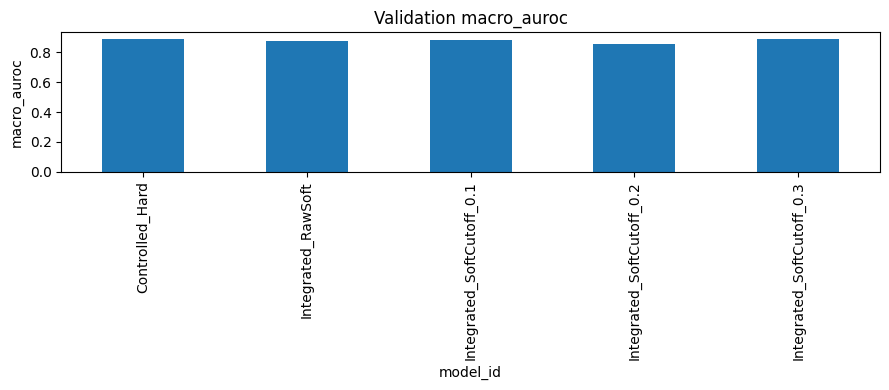

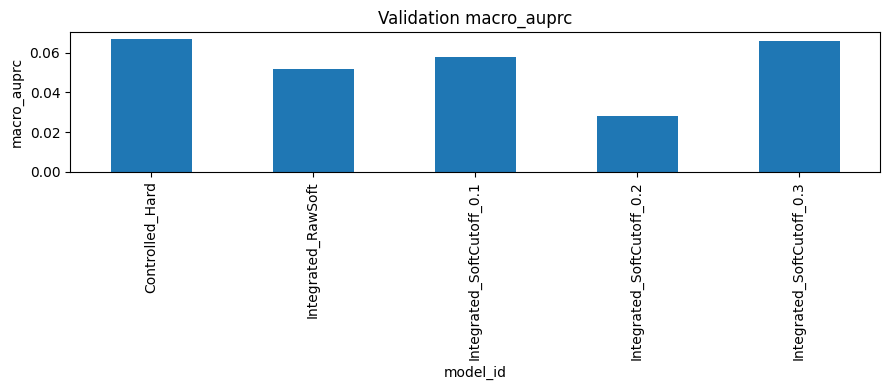

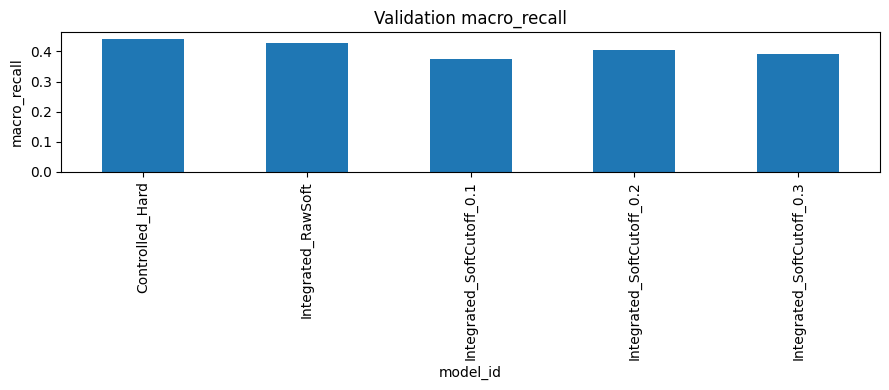

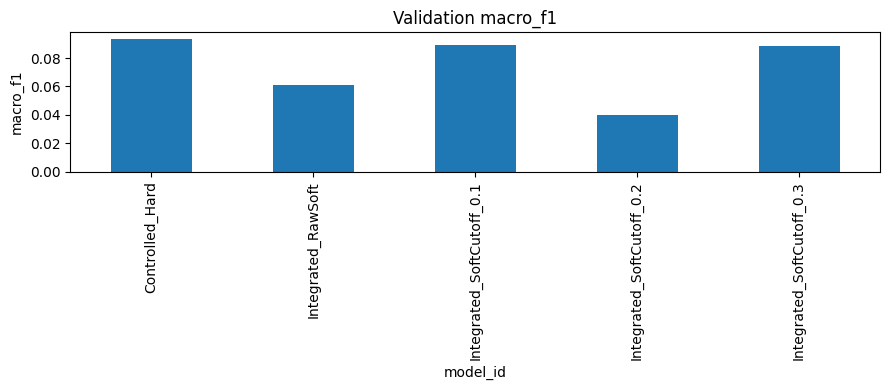

In [10]:
# =============================================================================
# Complete Validation comparison: ranking and fixed 0.5 operating point
# =============================================================================

global_rows = []
per_class_frames = []
for model_id in MODEL_ORDER:
    metrics = evaluate_multilabel(val_targets, val_probs_by_model[model_id], FIXED_THRESHOLD)
    global_rows.append({"model_id": model_id, **metrics})
    frame = evaluate_per_class(val_targets, val_probs_by_model[model_id], FIXED_THRESHOLD)
    frame.insert(0, "model_id", model_id)
    per_class_frames.append(frame)

validation_global_metrics_df = pd.DataFrame(global_rows)
validation_per_class_metrics_df = pd.concat(per_class_frames, ignore_index=True)

hard_global = validation_global_metrics_df.set_index("model_id").loc["Controlled_Hard"]
metric_columns = [c for c in validation_global_metrics_df.columns if c not in {"model_id", "threshold"}]
for metric in metric_columns:
    validation_global_metrics_df[f"delta_{metric}_vs_hard"] = validation_global_metrics_df[metric] - hard_global[metric]

hard_per_class = validation_per_class_metrics_df[
    validation_per_class_metrics_df["model_id"] == "Controlled_Hard"
].set_index("label")
for metric in ["auroc", "auprc", "precision", "recall", "f1"]:
    validation_per_class_metrics_df[f"delta_{metric}_vs_hard"] = validation_per_class_metrics_df.apply(
        lambda row: row[metric] - hard_per_class.loc[row["label"], metric], axis=1
    )

validation_global_metrics_df.to_csv(OUTPUT_DIR / "validation_global_metrics_fixed_0.5.csv", index=False)
validation_per_class_metrics_df.to_csv(OUTPUT_DIR / "validation_per_class_metrics_fixed_0.5.csv", index=False)
display(validation_global_metrics_df)
display(validation_per_class_metrics_df)

# Default-color plots; numerical CSVs remain the source of truth.
plot_metrics = ["macro_auroc", "macro_auprc", "macro_recall", "macro_f1"]
for metric in plot_metrics:
    ax = validation_global_metrics_df.set_index("model_id")[metric].plot(kind="bar", figsize=(9, 4), title=f"Validation {metric}")
    ax.set_ylabel(metric)
    plt.tight_layout()
    path = FIGURE_DIR / f"validation_{metric}.png"
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


In [11]:
# =============================================================================
# Per-WSI and leave-one-WSI-out robustness audit
# =============================================================================

wsi_global_rows: List[Dict[str, Any]] = []
wsi_class_rows: List[Dict[str, Any]] = []
for wsi in val_wsis:
    mask = val_slide_ids == wsi
    y_wsi = val_targets[mask]
    for model_id in MODEL_ORDER:
        p_wsi = val_probs_by_model[model_id][mask]
        metrics = evaluate_multilabel(y_wsi, p_wsi, FIXED_THRESHOLD)
        wsi_global_rows.append({"WSI": wsi, "model_id": model_id, "rows": int(mask.sum()), **metrics})
        class_frame = evaluate_per_class(y_wsi, p_wsi, FIXED_THRESHOLD)
        class_frame.insert(0, "model_id", model_id)
        class_frame.insert(0, "WSI", wsi)
        wsi_class_rows.extend(class_frame.to_dict("records"))

validation_wsi_global_metrics_df = pd.DataFrame(wsi_global_rows)
validation_wsi_per_class_metrics_df = pd.DataFrame(wsi_class_rows)
validation_wsi_global_metrics_df.to_csv(OUTPUT_DIR / "validation_per_wsi_global_metrics.csv", index=False)
validation_wsi_per_class_metrics_df.to_csv(OUTPUT_DIR / "validation_per_wsi_per_class_metrics.csv", index=False)

# Focused per-WSI comparison for Irregular epithelial stratification.
target_wsi = validation_wsi_per_class_metrics_df[
    validation_wsi_per_class_metrics_df["label"] == TARGET_CLASS
].copy()
target_wsi_wide = target_wsi.pivot(index="WSI", columns="model_id", values=["positive_count", "auroc", "auprc", "recall", "f1"])
target_wsi_wide.columns = [f"{metric}__{model_id}" for metric, model_id in target_wsi_wide.columns]
target_wsi_wide = target_wsi_wide.reset_index()
for metric in ["auroc", "auprc", "recall", "f1"]:
    target_wsi_wide[f"delta_{metric}_raw_vs_hard"] = (
        target_wsi_wide[f"{metric}__Integrated_RawSoft"] - target_wsi_wide[f"{metric}__Controlled_Hard"]
    )
target_wsi_wide.to_csv(OUTPUT_DIR / "irregular_per_wsi_hard_vs_rawsoft.csv", index=False)
display(target_wsi_wide)

# Leave one WSI out, evaluate the pooled remaining five WSIs. This detects whether
# the full-Validation difference collapses when a single WSI is removed.
loo_rows = []
for excluded_wsi in val_wsis:
    mask = val_slide_ids != excluded_wsi
    y = val_targets[mask, TARGET_CLASS_INDEX]
    row: Dict[str, Any] = {
        "excluded_WSI": excluded_wsi,
        "included_rows": int(mask.sum()),
        "included_positive_count": int(y.sum()),
    }
    for model_id in ["Controlled_Hard", "Integrated_RawSoft"]:
        score = val_probs_by_model[model_id][mask, TARGET_CLASS_INDEX]
        pred = (score >= FIXED_THRESHOLD).astype(np.int8)
        p, r, f1, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
        row[f"auroc__{model_id}"] = safe_auroc(y, score)
        row[f"auprc__{model_id}"] = safe_auprc(y, score)
        row[f"recall__{model_id}"] = float(r)
        row[f"f1__{model_id}"] = float(f1)
    for metric in ["auroc", "auprc", "recall", "f1"]:
        row[f"delta_{metric}_raw_vs_hard"] = row[f"{metric}__Integrated_RawSoft"] - row[f"{metric}__Controlled_Hard"]
    loo_rows.append(row)

irregular_loo_exclusion_df = pd.DataFrame(loo_rows)
irregular_loo_exclusion_df.to_csv(OUTPUT_DIR / "irregular_leave_one_wsi_out_exclusion.csv", index=False)
display(irregular_loo_exclusion_df)

direction_rows = []
for metric in ["auroc", "auprc", "recall", "f1"]:
    values = irregular_loo_exclusion_df[f"delta_{metric}_raw_vs_hard"].dropna()
    direction_rows.append({
        "metric": metric,
        "valid_exclusions": len(values),
        "positive_exclusions": int((values > 0).sum()),
        "nonnegative_exclusions": int((values >= 0).sum()),
        "negative_exclusions": int((values < 0).sum()),
        "median_delta": float(values.median()) if len(values) else np.nan,
        "min_delta": float(values.min()) if len(values) else np.nan,
        "max_delta": float(values.max()) if len(values) else np.nan,
    })
irregular_direction_summary_df = pd.DataFrame(direction_rows)
irregular_direction_summary_df.to_csv(OUTPUT_DIR / "irregular_loo_direction_summary.csv", index=False)
display(irregular_direction_summary_df)


,WSI,positive_count__Controlled_Hard,positive_count__Integrated_RawSoft,positive_count__Integrated_SoftCutoff_0.1,positive_count__Integrated_SoftCutoff_0.2,positive_count__Integrated_SoftCutoff_0.3,auroc__Controlled_Hard,auroc__Integrated_RawSoft,auroc__Integrated_SoftCutoff_0.1,auroc__Integrated_SoftCutoff_0.2,...,recall__Integrated_SoftCutoff_0.3,f1__Controlled_Hard,f1__Integrated_RawSoft,f1__Integrated_SoftCutoff_0.1,f1__Integrated_SoftCutoff_0.2,f1__Integrated_SoftCutoff_0.3,delta_auroc_raw_vs_hard,delta_auprc_raw_vs_hard,delta_recall_raw_vs_hard,delta_f1_raw_vs_hard
0,1253-DP-12,17.0,17.0,17.0,17.0,17.0,0.956718,0.974866,0.965218,0.947726,...,0.000000,0.0,0.0,0.0,0.0,0.00000,0.018149,0.001429,0.0,0.0
1,1318-DP-08,146.0,146.0,146.0,146.0,146.0,0.783826,0.725304,0.756109,0.760576,...,0.000000,0.0,0.0,0.0,0.0,0.00000,-0.058521,-0.009062,0.0,0.0
2,1467-DP-12,22.0,22.0,22.0,22.0,22.0,0.803122,0.766763,0.876606,0.772011,...,0.090909,0.0,0.0,0.0,0.0,0.02649,-0.036359,-0.000349,0.0,0.0
3,168-DP-09,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.0,0.0,0.00000,NaN,NaN,0.0,0.0
4,895-DP-09,183.0,183.0,183.0,183.0,183.0,0.402841,0.414033,0.429348,0.652516,...,0.000000,0.0,0.0,0.0,0.0,0.00000,0.011193,0.000178,0.0,0.0
5,D706-12-1-i,8.0,8.0,8.0,8.0,8.0,0.532735,0.471799,0.491876,0.596836,...,0.000000,0.0,0.0,0.0,0.0,0.00000,-0.060936,-0.000653,0.0,0.0


,excluded_WSI,included_rows,included_positive_count,auroc__Controlled_Hard,auprc__Controlled_Hard,recall__Controlled_Hard,f1__Controlled_Hard,auroc__Integrated_RawSoft,auprc__Integrated_RawSoft,recall__Integrated_RawSoft,f1__Integrated_RawSoft,delta_auroc_raw_vs_hard,delta_auprc_raw_vs_hard,delta_recall_raw_vs_hard,delta_f1_raw_vs_hard
0,1253-DP-12,109979,359,0.636954,0.004228,0.0,0.0,0.591471,0.003625,0.0,0.0,-0.045483,-0.000604,0.0,0.0
1,1318-DP-08,180242,230,0.753060,0.002332,0.0,0.0,0.744709,0.002309,0.0,0.0,-0.008351,-0.000023,0.0,0.0
2,1467-DP-12,167483,354,0.785216,0.004658,0.0,0.0,0.750410,0.003873,0.0,0.0,-0.034806,-0.000785,0.0,0.0
3,168-DP-09,181098,376,0.792235,0.004760,0.0,0.0,0.779247,0.004382,0.0,0.0,-0.012988,-0.000377,0.0,0.0
4,895-DP-09,160293,193,0.890547,0.006003,0.0,0.0,0.846826,0.003743,0.0,0.0,-0.043721,-0.002260,0.0,0.0
5,D706-12-1-i,191320,368,0.788401,0.004295,0.0,0.0,0.753085,0.003556,0.0,0.0,-0.035316,-0.000739,0.0,0.0


,metric,valid_exclusions,positive_exclusions,nonnegative_exclusions,negative_exclusions,median_delta,min_delta,max_delta
0,auroc,6,0,0,6,-0.035061,-0.045483,-0.008351
1,auprc,6,0,0,6,-0.000671,-0.002260,-0.000023
2,recall,6,0,6,0,0.000000,0.000000,0.000000
3,f1,6,0,6,0,0.000000,0.000000,0.000000


In [12]:
# =============================================================================
# Boundary/error audit for Irregular epithelial stratification
# =============================================================================

hard_prob = val_probs_by_model["Controlled_Hard"][:, TARGET_CLASS_INDEX]
soft_prob = val_probs_by_model["Integrated_RawSoft"][:, TARGET_CLASS_INDEX]
hard_target = val_targets[:, TARGET_CLASS_INDEX]
soft_overlap = soft_val_df[TARGET_CLASS].to_numpy(dtype=np.float32)


def overlap_bin(values: np.ndarray) -> pd.Categorical:
    labels = ["0", "(0,0.1)", "[0.1,0.3)", "[0.3,0.5)", "[0.5,1.0]"]
    result = np.full(len(values), "0", dtype=object)
    result[(values > 0) & (values < 0.1)] = "(0,0.1)"
    result[(values >= 0.1) & (values < 0.3)] = "[0.1,0.3)"
    result[(values >= 0.3) & (values < 0.5)] = "[0.3,0.5)"
    result[values >= 0.5] = "[0.5,1.0]"
    return pd.Categorical(result, categories=labels, ordered=True)


boundary_df = hard_val_df[[c for c in ["slide_name", "filename", "x", "y", "filepath"] if c in hard_val_df.columns]].copy()
boundary_df["row_index"] = np.arange(len(boundary_df), dtype=np.int64)
boundary_df["hard_target"] = hard_target
boundary_df["soft_overlap"] = soft_overlap
boundary_df["overlap_bin"] = overlap_bin(soft_overlap)
boundary_df["hard_probability"] = hard_prob
boundary_df["raw_soft_probability"] = soft_prob
boundary_df["probability_delta_raw_minus_hard"] = soft_prob - hard_prob
boundary_df["hard_prediction_0.5"] = (hard_prob >= FIXED_THRESHOLD).astype(np.int8)
boundary_df["raw_soft_prediction_0.5"] = (soft_prob >= FIXED_THRESHOLD).astype(np.int8)

conditions = [
    (boundary_df["hard_prediction_0.5"] == boundary_df["hard_target"]) & (boundary_df["raw_soft_prediction_0.5"] == boundary_df["hard_target"]),
    (boundary_df["hard_prediction_0.5"] != boundary_df["hard_target"]) & (boundary_df["raw_soft_prediction_0.5"] == boundary_df["hard_target"]),
    (boundary_df["hard_prediction_0.5"] == boundary_df["hard_target"]) & (boundary_df["raw_soft_prediction_0.5"] != boundary_df["hard_target"]),
]
choices = ["both_correct", "hard_wrong_raw_correct", "hard_correct_raw_wrong"]
boundary_df["hard_label_error_category"] = np.select(conditions, choices, default="both_wrong")

# Semantically safer categories for the uncertain boundary region.
boundary_df["semantic_category"] = "other"
boundary_df.loc[
    (boundary_df["hard_target"] == 1) & (boundary_df["hard_prediction_0.5"] == 0) & (boundary_df["raw_soft_prediction_0.5"] == 1),
    "semantic_category",
] = "hard_positive_FN_corrected_by_raw"
boundary_df.loc[
    (boundary_df["hard_target"] == 1) & (boundary_df["hard_prediction_0.5"] == 1) & (boundary_df["raw_soft_prediction_0.5"] == 0),
    "semantic_category",
] = "hard_positive_regression_under_raw"
boundary_df.loc[
    (boundary_df["hard_target"] == 0) & (boundary_df["soft_overlap"] > 0) & (boundary_df["soft_overlap"] < 0.5),
    "semantic_category",
] = "soft_only_uncertain_boundary"
boundary_df.loc[
    (boundary_df["hard_target"] == 0) & (boundary_df["soft_overlap"] == 0),
    "semantic_category",
] = "pure_hard_negative_no_overlap"

boundary_df.to_csv(OUTPUT_DIR / "irregular_validation_patch_level_boundary_audit.csv", index=False)

summary_rows = []
for (bin_name, wsi), group in boundary_df.groupby(["overlap_bin", "slide_name"], observed=False):
    summary_rows.append({
        "overlap_bin": str(bin_name),
        "WSI": str(wsi),
        "patch_count": len(group),
        "hard_positive_count": int(group["hard_target"].sum()),
        "mean_hard_probability": float(group["hard_probability"].mean()),
        "mean_raw_soft_probability": float(group["raw_soft_probability"].mean()),
        "mean_probability_delta": float(group["probability_delta_raw_minus_hard"].mean()),
        "hard_predicted_positive_rate": float(group["hard_prediction_0.5"].mean()),
        "raw_soft_predicted_positive_rate": float(group["raw_soft_prediction_0.5"].mean()),
        "hard_wrong_raw_correct_count": int((group["hard_label_error_category"] == "hard_wrong_raw_correct").sum()),
        "hard_correct_raw_wrong_count": int((group["hard_label_error_category"] == "hard_correct_raw_wrong").sum()),
    })
boundary_bin_wsi_summary_df = pd.DataFrame(summary_rows)
boundary_bin_wsi_summary_df.to_csv(OUTPUT_DIR / "irregular_boundary_bin_by_wsi_summary.csv", index=False)
display(boundary_bin_wsi_summary_df)

semantic_summary_df = (
    boundary_df.groupby(["semantic_category", "slide_name"], observed=False)
    .agg(
        patch_count=("row_index", "size"),
        mean_soft_overlap=("soft_overlap", "mean"),
        mean_hard_probability=("hard_probability", "mean"),
        mean_raw_soft_probability=("raw_soft_probability", "mean"),
        mean_probability_delta=("probability_delta_raw_minus_hard", "mean"),
    )
    .reset_index()
)
semantic_summary_df.to_csv(OUTPUT_DIR / "irregular_semantic_error_summary_by_wsi.csv", index=False)
display(semantic_summary_df)

# Explicit concentration audit: a large raw count from one slide is not multi-WSI evidence.
corrected = boundary_df[boundary_df["semantic_category"] == "hard_positive_FN_corrected_by_raw"]
regressed = boundary_df[boundary_df["semantic_category"] == "hard_positive_regression_under_raw"]
concentration_df = pd.DataFrame([
    {
        "category": "hard_positive_FN_corrected_by_raw",
        "patch_count": len(corrected),
        "WSI_count": corrected["slide_name"].nunique(),
        "largest_WSI_share": float(corrected["slide_name"].value_counts(normalize=True).iloc[0]) if len(corrected) else np.nan,
    },
    {
        "category": "hard_positive_regression_under_raw",
        "patch_count": len(regressed),
        "WSI_count": regressed["slide_name"].nunique(),
        "largest_WSI_share": float(regressed["slide_name"].value_counts(normalize=True).iloc[0]) if len(regressed) else np.nan,
    },
])
concentration_df.to_csv(OUTPUT_DIR / "irregular_error_concentration_audit.csv", index=False)
display(concentration_df)


,overlap_bin,WSI,patch_count,hard_positive_count,mean_hard_probability,mean_raw_soft_probability,mean_probability_delta,hard_predicted_positive_rate,raw_soft_predicted_positive_rate,hard_wrong_raw_correct_count,hard_correct_raw_wrong_count
0,0,1253-DP-12,88072,0,0.005635,0.004971,-0.000665,0.000227,0.000045,19,3
1,0,1318-DP-08,17619,0,0.054442,0.022499,-0.031944,0.000851,0.000000,15,0
2,0,1467-DP-12,30554,0,0.044483,0.021322,-0.023161,0.006546,0.000065,198,0
3,0,168-DP-09,16985,0,0.065461,0.076605,0.011145,0.014012,0.014307,167,172
4,0,895-DP-09,37517,0,0.107496,0.065981,-0.041516,0.027321,0.002745,984,62
5,0,D706-12-1-i,6747,0,0.048700,0.009407,-0.039293,0.002668,0.000000,18,0
6,"(0,0.1)",1253-DP-12,5,0,0.027785,0.045456,0.017671,0.000000,0.000000,0,0
7,"(0,0.1)",1318-DP-08,35,0,0.098609,0.036656,-0.061954,0.000000,0.000000,0,0
8,"(0,0.1)",1467-DP-12,9,0,0.044315,0.016249,-0.028067,0.000000,0.000000,0,0
9,"(0,0.1)",895-DP-09,38,0,0.060852,0.064239,0.003387,0.000000,0.000000,0,0


,semantic_category,slide_name,patch_count,mean_soft_overlap,mean_hard_probability,mean_raw_soft_probability,mean_probability_delta
0,other,1253-DP-12,17,0.873060,0.066794,0.059125,-0.007670
1,other,1318-DP-08,146,0.898006,0.126985,0.038441,-0.088544
2,other,1467-DP-12,22,0.806672,0.085930,0.027541,-0.058389
3,other,895-DP-09,183,0.903145,0.046822,0.040828,-0.005995
4,other,D706-12-1-i,8,0.731617,0.052125,0.007506,-0.044619
5,pure_hard_negative_no_overlap,1253-DP-12,88072,0.000000,0.005635,0.004971,-0.000665
6,pure_hard_negative_no_overlap,1318-DP-08,17619,0.000000,0.054442,0.022499,-0.031944
7,pure_hard_negative_no_overlap,1467-DP-12,30554,0.000000,0.044483,0.021322,-0.023161
8,pure_hard_negative_no_overlap,168-DP-09,16985,0.000000,0.065461,0.076605,0.011145
9,pure_hard_negative_no_overlap,895-DP-09,37517,0.000000,0.107496,0.065981,-0.041516


,category,patch_count,WSI_count,largest_WSI_share
0,hard_positive_FN_corrected_by_raw,0,0,NaN
1,hard_positive_regression_under_raw,0,0,NaN


,review_category,row_index,slide_name,filename,x,y,filepath,hard_target,soft_overlap,hard_probability,raw_soft_probability,probability_delta_raw_minus_hard,manual_has_irregular_structure,manual_context_needed,manual_annotation_edge_only,manual_plausible_label_noise,reviewer_note
0,soft_only_boundary_largest_raw_increase,37016,895-DP-09,895-DP-09_tile_0013268.jpg,97664,287168,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.041440,0.243157,0.411656,0.168499,,,,,
1,soft_only_boundary_largest_raw_increase,37620,895-DP-09,895-DP-09_tile_0013872.jpg,91168,289856,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.358947,0.026959,0.114374,0.087415,,,,,
2,soft_only_boundary_largest_raw_increase,85081,1253-DP-12,1253-DP-12_tile_0023543.jpg,194656,134848,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.000242,0.083040,0.131708,0.048668,,,,,
3,soft_only_boundary_largest_raw_increase,84948,1253-DP-12,1253-DP-12_tile_0023410.jpg,193760,134400,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.028661,0.032520,0.071552,0.039032,,,,,
4,soft_only_boundary_largest_raw_increase,152871,1318-DP-08,1318-DP-08_tile_0003229.jpg,67648,276864,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.018814,0.014123,0.019221,0.005098,,,,,
5,soft_only_boundary_largest_raw_increase,3186,D706-12-1-i,D706-12-1-i_tile_0003186.jpg,110208,328160,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.040614,0.004181,0.008539,0.004358,,,,,
6,soft_only_boundary_largest_raw_increase,152994,1318-DP-08,1318-DP-08_tile_0003352.jpg,67648,277312,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.045577,0.018233,0.022170,0.003937,,,,,
7,soft_only_boundary_largest_raw_increase,3166,D706-12-1-i,D706-12-1-i_tile_0003166.jpg,109984,327936,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.351558,0.001991,0.003325,0.001334,,,,,
8,soft_only_boundary_highest_overlap,39092,895-DP-09,895-DP-09_tile_0015344.jpg,88928,294112,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.491941,0.074954,0.051661,-0.023293,,,,,
9,soft_only_boundary_highest_overlap,151959,1318-DP-08,1318-DP-08_tile_0002317.jpg,64288,273280,/scr/user/jiangjie/Jiangjie_Project/data/Resea...,0,0.488555,0.124138,0.018637,-0.105501,,,,,


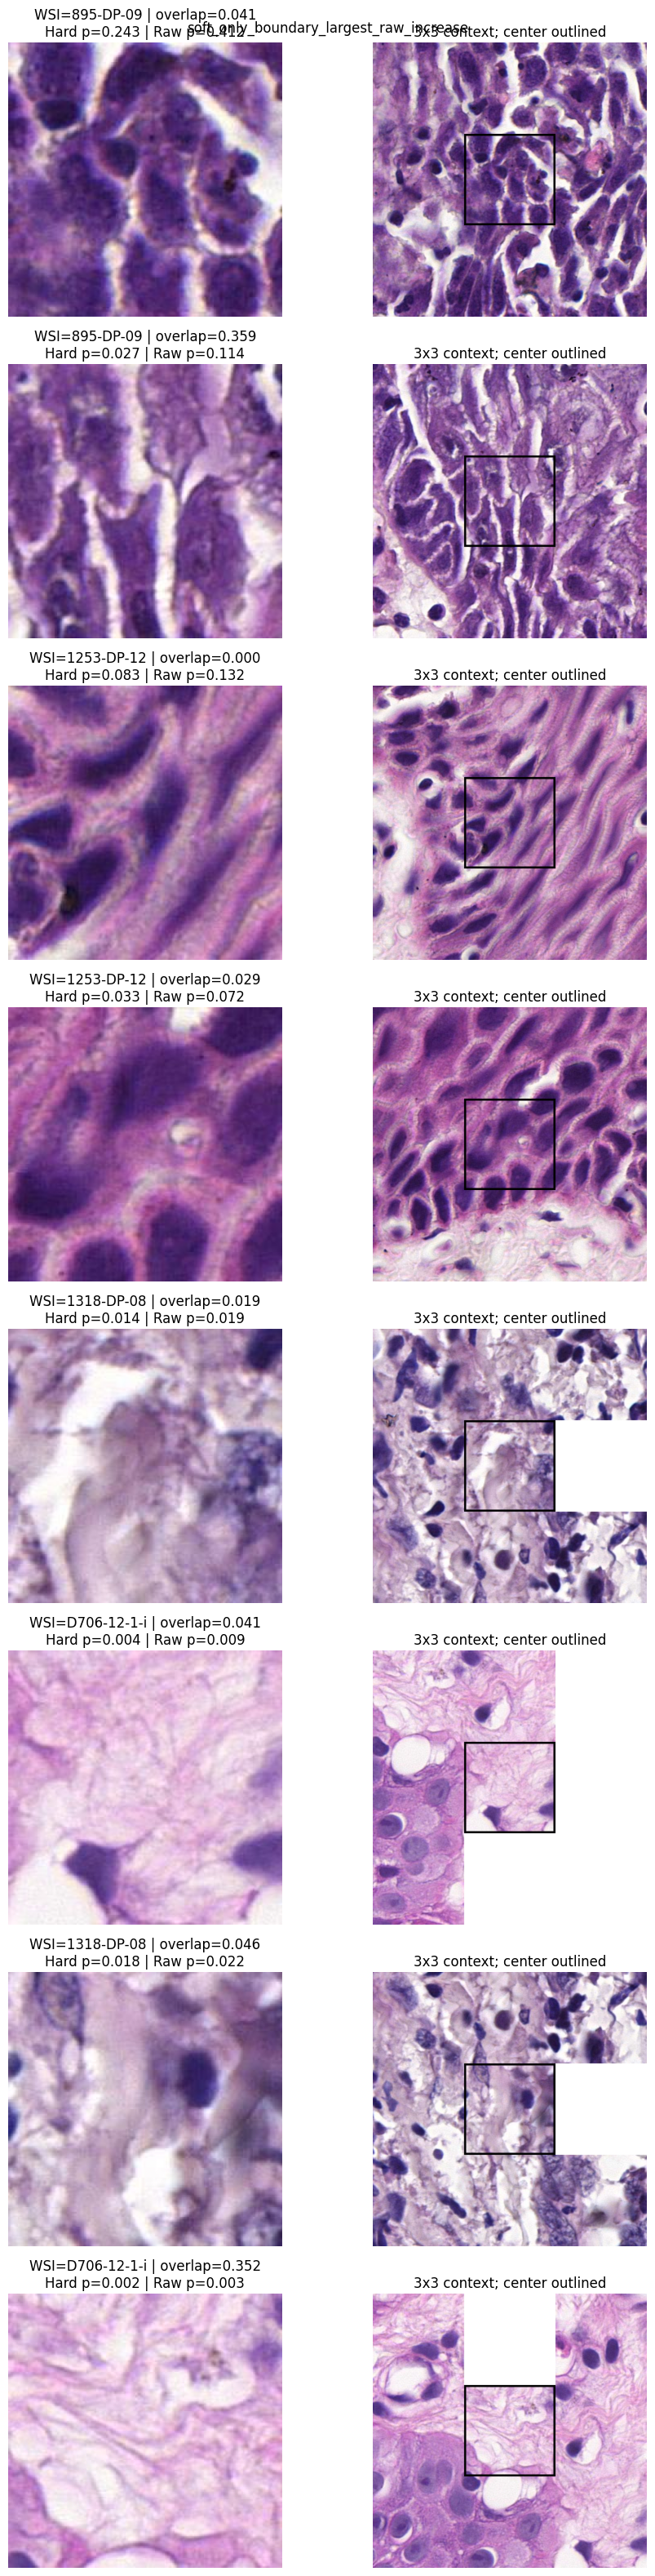

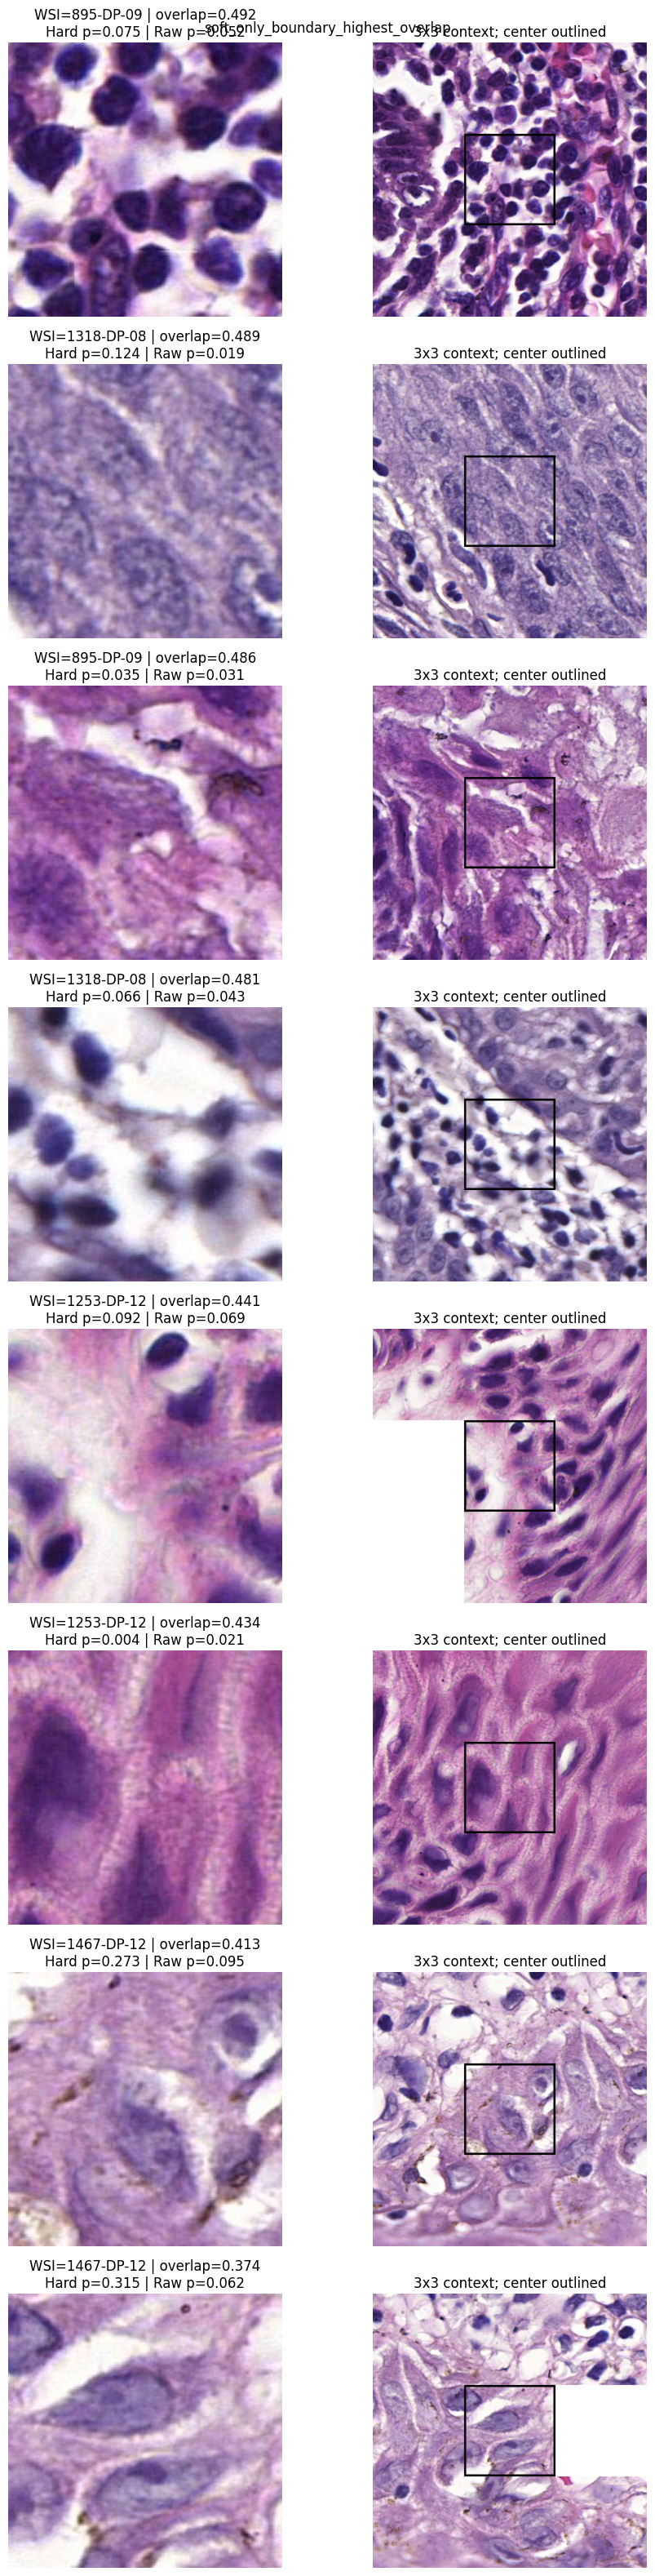

,review_category,contact_sheet,status
0,soft_only_boundary_largest_raw_increase,/scr/user/jiangjie/Jiangjie_Project/outputs/rq...,created
1,soft_only_boundary_highest_overlap,/scr/user/jiangjie/Jiangjie_Project/outputs/rq...,created


In [13]:
# =============================================================================
# Deterministic representative-case export and 3x3 context review
# =============================================================================


def diverse_top_rows(frame: pd.DataFrame, score_column: str, n: int, max_per_wsi: int, ascending: bool = False) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    ordered = frame.sort_values([score_column, "row_index"], ascending=[ascending, True])
    selected_indices = []
    per_wsi: Dict[str, int] = {}
    for index, row in ordered.iterrows():
        wsi = str(row["slide_name"])
        if per_wsi.get(wsi, 0) >= max_per_wsi:
            continue
        selected_indices.append(index)
        per_wsi[wsi] = per_wsi.get(wsi, 0) + 1
        if len(selected_indices) >= n:
            break
    return frame.loc[selected_indices].copy()


review_frames = []
review_specs = [
    (
        "hard_positive_FN_corrected_by_raw",
        boundary_df[boundary_df["semantic_category"] == "hard_positive_FN_corrected_by_raw"],
        "probability_delta_raw_minus_hard",
        False,
    ),
    (
        "hard_positive_regression_under_raw",
        boundary_df[boundary_df["semantic_category"] == "hard_positive_regression_under_raw"],
        "probability_delta_raw_minus_hard",
        True,
    ),
    (
        "soft_only_boundary_largest_raw_increase",
        boundary_df[boundary_df["semantic_category"] == "soft_only_uncertain_boundary"],
        "probability_delta_raw_minus_hard",
        False,
    ),
    (
        "soft_only_boundary_highest_overlap",
        boundary_df[boundary_df["semantic_category"] == "soft_only_uncertain_boundary"],
        "soft_overlap",
        False,
    ),
]
for category, frame, score_column, ascending in review_specs:
    selected = diverse_top_rows(
        frame,
        score_column=score_column,
        n=NUM_REVIEW_EXAMPLES_PER_CATEGORY,
        max_per_wsi=MAX_EXAMPLES_PER_WSI,
        ascending=ascending,
    )
    if not selected.empty:
        selected.insert(0, "review_category", category)
        review_frames.append(selected)

review_examples_df = pd.concat(review_frames, ignore_index=True) if review_frames else pd.DataFrame()
review_examples_path = REVIEW_DIR / "irregular_manual_review_examples.csv"
review_examples_df.to_csv(review_examples_path, index=False)

review_sheet_columns = [
    "review_category", "row_index", "slide_name", "filename", "x", "y", "filepath",
    "hard_target", "soft_overlap", "hard_probability", "raw_soft_probability",
    "probability_delta_raw_minus_hard", "manual_has_irregular_structure",
    "manual_context_needed", "manual_annotation_edge_only", "manual_plausible_label_noise",
    "reviewer_note",
]
review_sheet = review_examples_df.copy()
for column in review_sheet_columns:
    if column not in review_sheet.columns:
        review_sheet[column] = ""
review_sheet = review_sheet[review_sheet_columns]
review_sheet.to_csv(REVIEW_DIR / "irregular_manual_review_sheet_to_fill.csv", index=False)
display(review_sheet)


def safe_open_rgb(path: Path, size: Tuple[int, int] = (TILE_SIZE, TILE_SIZE)) -> Image.Image:
    try:
        with Image.open(path) as image:
            return image.convert("RGB").resize(size)
    except Exception:
        image = Image.new("RGB", size, "white")
        draw = ImageDraw.Draw(image)
        draw.text((8, 8), "missing", fill="black")
        return image


def coordinate_key(slide: str, x: Any, y: Any) -> Tuple[str, int, int]:
    return str(slide), int(round(float(x))), int(round(float(y)))


coordinate_to_path: Dict[Tuple[str, int, int], str] = {}
if all(column in hard_val_df.columns for column in ["slide_name", "x", "y", "filepath"]):
    for row in hard_val_df[["slide_name", "x", "y", "filepath"]].itertuples(index=False):
        coordinate_to_path[coordinate_key(row.slide_name, row.x, row.y)] = str(row.filepath)


def context_mosaic(slide: str, x: Any, y: Any) -> Image.Image:
    center_x, center_y = int(round(float(x))), int(round(float(y)))
    mosaic = Image.new("RGB", (TILE_SIZE * 3, TILE_SIZE * 3), "white")
    for row_offset, dy in enumerate([-TILE_SIZE, 0, TILE_SIZE]):
        for col_offset, dx in enumerate([-TILE_SIZE, 0, TILE_SIZE]):
            raw_path = coordinate_to_path.get((str(slide), center_x + dx, center_y + dy))
            tile = safe_open_rgb(normalize_patch_path(raw_path)) if raw_path else Image.new("RGB", (TILE_SIZE, TILE_SIZE), "white")
            mosaic.paste(tile, (col_offset * TILE_SIZE, row_offset * TILE_SIZE))
    draw = ImageDraw.Draw(mosaic)
    draw.rectangle(
        [TILE_SIZE, TILE_SIZE, TILE_SIZE * 2 - 1, TILE_SIZE * 2 - 1],
        outline="black",
        width=5,
    )
    return mosaic


def save_review_contact_sheet(category: str, frame: pd.DataFrame) -> Optional[Path]:
    if frame.empty:
        return None
    rows = len(frame)
    fig, axes = plt.subplots(rows, 2, figsize=(10, 4 * rows), squeeze=False)
    for axis_row, (_, item) in zip(axes, frame.iterrows()):
        center_path = normalize_patch_path(item["filepath"])
        center = safe_open_rgb(center_path)
        context = context_mosaic(item["slide_name"], item["x"], item["y"])
        axis_row[0].imshow(center)
        axis_row[1].imshow(context)
        title = (
            f"WSI={item['slide_name']} | overlap={item['soft_overlap']:.3f}\n"
            f"Hard p={item['hard_probability']:.3f} | Raw p={item['raw_soft_probability']:.3f}"
        )
        axis_row[0].set_title(title)
        axis_row[1].set_title("3x3 context; center outlined")
        axis_row[0].axis("off")
        axis_row[1].axis("off")
    fig.suptitle(category)
    plt.tight_layout()
    output_path = REVIEW_DIR / f"{category}_contact_sheet.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    return output_path


contact_sheet_rows = []
if RUN_IMAGE_REVIEW and not review_examples_df.empty:
    for category, group in review_examples_df.groupby("review_category", sort=False):
        try:
            path = save_review_contact_sheet(category, group)
            contact_sheet_rows.append({"review_category": category, "contact_sheet": str(path) if path else None, "status": "created"})
        except Exception as exc:
            contact_sheet_rows.append({"review_category": category, "contact_sheet": None, "status": f"failed: {exc}"})
else:
    contact_sheet_rows.append({"review_category": None, "contact_sheet": None, "status": "image review disabled or no examples"})
contact_sheet_manifest_df = pd.DataFrame(contact_sheet_rows)
contact_sheet_manifest_df.to_csv(REVIEW_DIR / "contact_sheet_manifest.csv", index=False)
display(contact_sheet_manifest_df)


In [14]:
# =============================================================================
# Locked decision synthesis
# =============================================================================

validation_global_indexed = validation_global_metrics_df.set_index("model_id")
hard_global = validation_global_indexed.loc["Controlled_Hard"]
raw_global = validation_global_indexed.loc["Integrated_RawSoft"]

# Overall replacement gate: ranking improvement alone is insufficient.
overall_ranking_gain = (
    raw_global["macro_auroc"] > hard_global["macro_auroc"]
    and raw_global["macro_auprc"] >= hard_global["macro_auprc"]
)
overall_operating_point_not_harmed = (
    raw_global["macro_recall"] >= hard_global["macro_recall"] - RECALL_F1_TOLERANCE
    and raw_global["macro_f1"] >= hard_global["macro_f1"] - RECALL_F1_TOLERANCE
)
overall_replacement_supported = bool(overall_ranking_gain and overall_operating_point_not_harmed)

per_class_indexed = validation_per_class_metrics_df.set_index(["model_id", "label"])
hard_target_metrics = per_class_indexed.loc[("Controlled_Hard", TARGET_CLASS)]
raw_target_metrics = per_class_indexed.loc[("Integrated_RawSoft", TARGET_CLASS)]
full_delta = {
    metric: float(raw_target_metrics[metric] - hard_target_metrics[metric])
    for metric in ["auroc", "auprc", "recall", "f1"]
}

loo_summary = irregular_direction_summary_df.set_index("metric")
valid_auc_exclusions = int(loo_summary.loc["auroc", "valid_exclusions"])
valid_ap_exclusions = int(loo_summary.loc["auprc", "valid_exclusions"])
robust_auc = valid_auc_exclusions > 0 and int(loo_summary.loc["auroc", "positive_exclusions"]) >= max(1, int(np.ceil(valid_auc_exclusions * 2 / 3)))
robust_ap = valid_ap_exclusions > 0 and int(loo_summary.loc["auprc", "positive_exclusions"]) >= max(1, int(np.ceil(valid_ap_exclusions * 2 / 3)))
validation_ranking_signal = (full_delta["auroc"] > 0) or (full_delta["auprc"] > 0)
not_single_wsi_only = bool(robust_auc or robust_ap)
local_operating_point_acceptable = bool(
    full_delta["auprc"] >= 0
    or full_delta["recall"] >= -RECALL_F1_TOLERANCE
)

if not validation_ranking_signal:
    local_signal_status = "STOP_NO_VALIDATION_SIGNAL"
elif not not_single_wsi_only:
    local_signal_status = "STOP_UNSTABLE_OR_SINGLE_WSI_DOMINATED"
elif not local_operating_point_acceptable:
    local_signal_status = "STOP_RANKING_GAIN_WITH_MATERIAL_AUPRC_RECALL_HARM"
elif not MANUAL_REVIEW_CONFIRMED:
    local_signal_status = "LOCAL_SIGNAL_REQUIRES_MANUAL_IMAGE_REVIEW"
else:
    local_signal_status = "LOCAL_SIGNAL_SUPPORTED_FOR_ONE_MINIMAL_CLASS_SPECIFIC_FOLLOWUP"

cutoff_metrics = validation_global_metrics_df[
    validation_global_metrics_df["model_id"].str.contains("SoftCutoff", regex=False)
].copy()
cutoff_consistency = {
    "num_cutoff_models": int(len(cutoff_metrics)),
    "all_cutoffs_beat_raw_macro_auroc": bool((cutoff_metrics["macro_auroc"] > raw_global["macro_auroc"]).all()) if len(cutoff_metrics) else None,
    "all_cutoffs_beat_hard_macro_auprc": bool((cutoff_metrics["macro_auprc"] > hard_global["macro_auprc"]).all()) if len(cutoff_metrics) else None,
    "best_cutoff_by_macro_auroc": cutoff_metrics.sort_values("macro_auroc", ascending=False).iloc[0]["model_id"] if len(cutoff_metrics) else None,
    "best_cutoff_by_macro_auprc": cutoff_metrics.sort_values("macro_auprc", ascending=False).iloc[0]["model_id"] if len(cutoff_metrics) else None,
}

final_decision = {
    "protocol_sha256": PROTOCOL_SHA256,
    "test_loaded": False,
    "overall_replacement_supported": overall_replacement_supported,
    "overall_decision": (
        "DO_NOT_REPLACE_CONTROLLED_HARD"
        if not overall_replacement_supported
        else "RAW_SOFT_REQUIRES_FURTHER_PRE_REGISTERED_CONFIRMATION"
    ),
    "overall_evidence": {
        "raw_minus_hard_macro_auroc": float(raw_global["macro_auroc"] - hard_global["macro_auroc"]),
        "raw_minus_hard_macro_auprc": float(raw_global["macro_auprc"] - hard_global["macro_auprc"]),
        "raw_minus_hard_macro_recall": float(raw_global["macro_recall"] - hard_global["macro_recall"]),
        "raw_minus_hard_macro_f1": float(raw_global["macro_f1"] - hard_global["macro_f1"]),
    },
    "integrated_experiment_is_target_only": False,
    "target_class": TARGET_CLASS,
    "target_class_full_validation_delta": full_delta,
    "target_class_robust_auc_across_loo_exclusions": robust_auc,
    "target_class_robust_auprc_across_loo_exclusions": robust_ap,
    "target_class_status": local_signal_status,
    "manual_review_confirmed": MANUAL_REVIEW_CONFIRMED,
    "cutoff_consistency": cutoff_consistency,
}

(OUTPUT_DIR / "final_audit_decision.json").write_text(
    json.dumps(final_decision, indent=2, sort_keys=True), encoding="utf-8"
)

summary_lines = [
    "# 06D Soft-label Validation-only Audit — Generated Summary",
    "",
    f"- Protocol SHA-256: `{PROTOCOL_SHA256}`",
    "- Test loaded: **No**",
    f"- Integrated experiment is target-only: **No**",
    f"- Overall decision: **{final_decision['overall_decision']}**",
    f"- Irregular epithelial stratification status: **{local_signal_status}**",
    "",
    "## Raw Soft minus Controlled Hard on complete Validation",
    f"- Macro AUROC: {final_decision['overall_evidence']['raw_minus_hard_macro_auroc']:+.6f}",
    f"- Macro AUPRC: {final_decision['overall_evidence']['raw_minus_hard_macro_auprc']:+.6f}",
    f"- Macro Recall@0.5: {final_decision['overall_evidence']['raw_minus_hard_macro_recall']:+.6f}",
    f"- Macro F1@0.5: {final_decision['overall_evidence']['raw_minus_hard_macro_f1']:+.6f}",
    "",
    "## Irregular epithelial stratification: Raw Soft minus Controlled Hard",
    *[f"- {metric}: {value:+.6f}" for metric, value in full_delta.items()],
    "",
    "## Interpretation",
    "- Raw Soft cannot replace Controlled Hard solely on an AUROC gain.",
    "- Any class-specific follow-up must remain Validation-driven and must pass manual boundary/context review.",
    "- Do not run additional cutoff searches based on Test results.",
]
summary_text = "\n".join(summary_lines)
(OUTPUT_DIR / "README_audit_summary.md").write_text(summary_text, encoding="utf-8")
display(Markdown(summary_text))
print("Saved final decision:", OUTPUT_DIR / "final_audit_decision.json")
print("Saved summary:", OUTPUT_DIR / "README_audit_summary.md")


# 06D Soft-label Validation-only Audit — Generated Summary

- Protocol SHA-256: `af2896f0d89930ad4b15cc3fe1bd50021f9b52d69cd5659ad1a6669d3b059e70`
- Test loaded: **No**
- Integrated experiment is target-only: **No**
- Overall decision: **DO_NOT_REPLACE_CONTROLLED_HARD**
- Irregular epithelial stratification status: **STOP_NO_VALIDATION_SIGNAL**

## Raw Soft minus Controlled Hard on complete Validation
- Macro AUROC: -0.011361
- Macro AUPRC: -0.015363
- Macro Recall@0.5: -0.013568
- Macro F1@0.5: -0.032463

## Irregular epithelial stratification: Raw Soft minus Controlled Hard
- auroc: -0.029714
- auprc: -0.000624
- recall: +0.000000
- f1: +0.000000

## Interpretation
- Raw Soft cannot replace Controlled Hard solely on an AUROC gain.
- Any class-specific follow-up must remain Validation-driven and must pass manual boundary/context review.
- Do not run additional cutoff searches based on Test results.

Saved final decision: /scr/user/jiangjie/Jiangjie_Project/outputs/rq1_soft_label_validation_audit/final_audit_decision.json
Saved summary: /scr/user/jiangjie/Jiangjie_Project/outputs/rq1_soft_label_validation_audit/README_audit_summary.md


## Manual completion step

After running the notebook:

1. Open the PNG contact sheets in `outputs/rq1_soft_label_validation_audit/manual_review/`.
2. Fill `irregular_manual_review_sheet_to_fill.csv` without looking at Test results.
3. Decide whether the cases show genuine irregular stratification, whether the 3×3 context is necessary, or whether the effect is mainly annotation-edge noise.
4. Only then change `MANUAL_REVIEW_CONFIRMED = True` and rerun the **decision synthesis cell only**.

Do not use manual review to tune a cutoff, threshold or checkpoint. Its only role is to decide whether one narrowly scoped class-specific follow-up is scientifically justified.
